# Neural Morse-guided search for the Clifford torus
**Henrique Tonello Pereira | AI for Geometry**

This is the single executable source for the project: mathematical definitions, training protocols, geometric validation, torus images and comparisons. No other notebook or historical result directory is required. All comparison tables are computed from runs generated by this notebook or its matching checkpoints; no archived numerical outputs are embedded.

**Run top to bottom.** Choose `EXECUTION_PROFILE` in section 1: `demo` generates the five illustrative runs; `central` also executes the controlled 165-run comparison and geometric validation; `complete` requests every registered experiment. Individual switches remain editable. Full execution can take many hours. Completed configurations are cached; partial interrupted runs start afresh.

**Submission workflow:** use `central` for the central conclusions, or `complete` for the entire suite. Inspect the execution audit in section 27. Update report numbers and figures from the exported outputs; do not assume that previous numerical results are reproduced. The demonstration alone does not establish the controlled sweep or the convergence maps.

**Validation status:** the revised notebook has been structurally checked, but not numerically executed in the preparation environment because PyTorch is unavailable. No new numerical outcomes are claimed.

## Setup
```bash
python3.12 -m venv .venv
source .venv/bin/activate
python -m pip install -r requirements.txt
jupyter lab clifford_morse_complete.ipynb
```
Windows activation: `.venv\Scripts\Activate.ps1`. Dependencies: numpy, scipy, torch, matplotlib, pandas, scikit-learn, jupyterlab. Training uses CPU and float64; the actual environment is exported at execution.


## Experiment coverage

| Block | Content |
|---|---|
| checks | Known areas, variable density, curvature, penalty, HVP, projector, toy saddle |
| baseline | Three starts, pure descent; local rank, angular conditioning and refinement |
| eps_ablation / pure_long | epsilon=0.08,0.01,0.001; 2000-step descent |
| penalty / penalty_repair | Lambda ablation, gradient scales, penalty-only repair |
| equivalence / demo / fine | k=0 equivalence, four views, 1000-step refinement |
| exploratory_k | Single-start k sweep, final vs historical gradient |
| robust / paired58 | All k=0,…,10, five starts, three seeds; paired k=5,8 |
| targeted_extension | 1500-step difficult starts; tau=1e-6 vs 1e-2 |
| spectral / representation | Jacobi controls/candidates, 24/48/96 grids, Richardson, seed robustness, decomposition |
| angular / coarse / frontier / transition | Radius-one slice, 5x5 map and additional seeds |
| budget / dense / anomalies | Five budget pairs, dense 9x9 map, anomaly seeds |
| analysis | Heatmaps, bins, ratio/scale cuts, logistic model, descriptive contours |

New fixed-budget analyses intentionally avoid silently reusing a 300-step run as a 500-step run. Rounded anomaly locations are treated as distinct from exact dense-grid points unless their exact configurations match.


## 1. Configuration and execution switches

In [51]:
import sys, time, math, json, hashlib, warnings, copy, inspect
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh, LinearOperator
from torch.func import functional_call
from IPython.display import display

DEVICE=torch.device('cpu')
DTYPE=torch.float64
torch.set_num_threads(1)
SEED=20260916
SEEDS=(20260916,20260917,20260918)
INITS=((.90,.40),(.70,.70),(.55,.85),(.95,.20),(.60,.60))
np.random.seed(SEED);torch.manual_seed(SEED)
N_U=N_V=48
DU=DV=2*np.pi/48
u0=torch.linspace(0,2*np.pi,49,dtype=DTYPE,device=DEVICE)[:-1]
v0=torch.linspace(0,2*np.pi,49,dtype=DTYPE,device=DEVICE)[:-1]
U0,V0=torch.meshgrid(u0,v0,indexing='ij')
W_QUAD=torch.full((48,48),DU*DV,dtype=DTYPE,device=DEVICE)
EPS_PROVISIONAL=.001
TOL_REG=1e-6
TAU_PENALTY=1e-2
LAMBDA_REG=.01
A_CLIFF=2*np.pi**2
OUT=Path('complete_results');OUT.mkdir(exist_ok=True)
CACHE=OUT/'checkpoints';CACHE.mkdir(exist_ok=True)
FIGS=OUT/'figures';FIGS.mkdir(exist_ok=True)
TABLES=OUT/'tables';TABLES.mkdir(exist_ok=True)
# demo: quick illustrative comparison; central: core report experiments;
# complete: all experiments including maps and proposed extensions.
EXECUTION_PROFILE='demo'
if EXECUTION_PROFILE not in ('demo','central','complete'):
    raise ValueError('Unknown execution profile')
RUN_ALL=(EXECUTION_PROFILE=='complete')
RUN=dict.fromkeys(['checks','baseline','eps_ablation','pure_long','penalty',
 'penalty_repair','hessian_states','equivalence','demo','fine','exploratory_k','robust','paired58',
 'targeted_extension','spectral','representation','angular','coarse','frontier',
 'transition','budget','dense','anomalies'],False)
RUN.update(checks=True,demo=True)
if EXECUTION_PROFILE=='central':
    RUN.update(baseline=True, eps_ablation=True, pure_long=True, penalty=True,
               equivalence=True, robust=True, paired58=True,
               spectral=True, representation=True, budget=True)
SPECTRAL_GRIDS=(24,48,96)
# Enable one or more families above, then rerun its cells.
# RUN_ALL requests all registered experiments, including labelled extensions.
FAIL_FAST=True
ENV=dict(python=sys.version.split()[0],torch=torch.__version__,numpy=np.__version__,scipy=scipy.__version__,device=str(DEVICE),threads=torch.get_num_threads())
(OUT/'environment.json').write_text(json.dumps(ENV,indent=2))
print(ENV)
print('Enabled:',[k for k,v in RUN.items() if v or RUN_ALL])

{'python': '3.12.13', 'torch': '2.13.0+cu130', 'numpy': '2.5.2', 'scipy': '1.18.0', 'device': 'cpu', 'threads': 1}
Enabled: ['checks', 'demo']


## 2. Geometry and neural representation
$X_\theta=(B_{a,b}+\varepsilon N_\theta(z))/|B_{a,b}+\varepsilon N_\theta(z)|$, with periodic features $z=(cos u,sin u,cos v,sin v)$, a tanh network $4\to32\to32\to4$ and positive trainable base radii. $D=EG-F^2$ is the induced metric determinant. The quadrature uses float64 on a periodic 48x48 grid. The area clamp is numerical protection; regularity is evaluated with the unclamped determinant.

In [52]:
def periodic_features(U, V):
    return torch.stack([torch.cos(U), torch.sin(U), torch.cos(V), torch.sin(V)], dim=-1)

class TorusMLP(nn.Module):

    def __init__(self, width=32, depth=2, a0=0.8, b0=0.6, eps=0.08):
        super().__init__()
        self.a_raw = nn.Parameter(torch.tensor(np.log(np.expm1(a0)), dtype=DTYPE, device=DEVICE))
        self.b_raw = nn.Parameter(torch.tensor(np.log(np.expm1(b0)), dtype=DTYPE, device=DEVICE))
        self.eps = float(eps)
        layers = [nn.Linear(4, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 4)]
        self.net = nn.Sequential(*layers).to(dtype=DTYPE, device=DEVICE)

    @property
    def a(self):
        return torch.nn.functional.softplus(self.a_raw) + 0.0001

    @property
    def b(self):
        return torch.nn.functional.softplus(self.b_raw) + 0.0001

    def _compute(self, feats):
        cu, su, cv, sv = feats.unbind(-1)
        base = torch.stack([self.a * cu, self.a * su, self.b * cv, self.b * sv], dim=-1)
        F = base + self.eps * self.net(feats)
        return F / F.norm(dim=-1, keepdim=True).clamp_min(1e-12)

    def forward_uv(self, U, V):
        return self._compute(periodic_features(U, V))

    def forward(self, feats):
        return self._compute(feats)

def make_clifford(U, V):
    return torch.stack([torch.cos(U), torch.sin(U), torch.cos(V), torch.sin(V)], dim=-1) / math.sqrt(2.0)

def pullback_from_uv(X, U, V, create_graph=False):
    Xu_components = []
    Xv_components = []
    for c in range(4):
        gu, gv = torch.autograd.grad(X[..., c].sum(), (U, V), retain_graph=True, create_graph=create_graph)
        Xu_components.append(gu)
        Xv_components.append(gv)
    Xu = torch.stack(Xu_components, dim=-1)
    Xv = torch.stack(Xv_components, dim=-1)
    E = (Xu * Xu).sum(dim=-1)
    F = (Xu * Xv).sum(dim=-1)
    G = (Xv * Xv).sum(dim=-1)
    det_g = E * G - F * F
    return (Xu, Xv, E, F, G, det_g)

def geometry(model, create_graph=False):
    U = U0.detach().clone().requires_grad_(True)
    V = V0.detach().clone().requires_grad_(True)
    X = model.forward_uv(U, V)
    Xu, Xv, E, F, G, det_g = pullback_from_uv(X, U, V, create_graph=create_graph)
    return (X, Xu, Xv, E, F, G, det_g)

def area_from_det(det_g):
    return (W_QUAD * torch.sqrt(det_g.clamp_min(1e-14))).sum()

def area(model, create_graph=False):
    *_, det_g = geometry(model, create_graph=create_graph)
    return area_from_det(det_g)

def area_and_det(model):
    *_, det_g = geometry(model, create_graph=False)
    return (area_from_det(det_g).detach(), det_g.detach())

In [53]:
FEATS0=periodic_features(U0,V0)
class AnalyticClifford:
    def forward_uv(self,U,V):return make_clifford(U,V)
class ProductTorus:
    def __init__(self,a=.9,b=.4):self.a,self.b=a,b
    def forward_uv(self,U,V):
        return torch.stack([self.a*torch.cos(U),self.a*torch.sin(U),self.b*torch.cos(V),self.b*torch.sin(V)],-1)/math.sqrt(self.a**2+self.b**2)
def make_variable_torus(delta=0.15):

    def builder(U, V):
        a = 1.0 + delta * torch.cos(U)
        b = 1.0 + delta * torch.cos(V)
        F = torch.stack([a * torch.cos(U), a * torch.sin(U), b * torch.cos(V), b * torch.sin(V)], dim=-1)
        return F / F.norm(dim=-1, keepdim=True)
    return builder

def area_on_periodic_grid(builder, n):
    u = torch.linspace(0, 2 * np.pi, n + 1, dtype=DTYPE, device=DEVICE)[:-1]
    v = torch.linspace(0, 2 * np.pi, n + 1, dtype=DTYPE, device=DEVICE)[:-1]
    U, V = torch.meshgrid(u, v, indexing='ij')
    U.requires_grad_(True)
    V.requires_grad_(True)
    X = builder(U, V)
    *_, det_g = pullback_from_uv(X, U, V, create_graph=False)
    weight = (2 * np.pi / n) ** 2
    A = weight * torch.sqrt(det_g.clamp_min(0)).sum()
    return (A.item(), det_g.detach())

## 3. Training methods — one definition of each

In [54]:
def flat_grad(model):
    return torch.cat([p.grad.detach().reshape(-1) for p in model.parameters() if p.requires_grad and p.grad is not None])

def evaluate_training_state(model):
    model.zero_grad(set_to_none=True)
    A = area(model, create_graph=True)
    A.backward()
    gnorm = flat_grad(model).norm().item()
    A_eval, det_eval = area_and_det(model)
    return (A_eval.item(), gnorm, det_eval.min().item())

def fit_gradient_descent(seed, a0, b0, steps=150, lr=0.003, width=32, depth=2, eps=0.08):
    torch.manual_seed(seed)
    model = TorusMLP(width=width, depth=depth, a0=a0, b0=b0, eps=eps).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist_A, hist_grad, hist_det = ([], [], [])
    for step in range(steps):
        opt.zero_grad(set_to_none=True)
        A = area(model, create_graph=True)
        A.backward()
        opt.step()
        A_eval, gnorm, min_det = evaluate_training_state(model)
        hist_A.append(A_eval)
        hist_grad.append(gnorm)
        hist_det.append(min_det)
    model.zero_grad(set_to_none=True)
    return {'model': model, 'optimizer_state': opt.state_dict(), 'A': np.array(hist_A), 'grad': np.array(hist_grad), 'det': np.array(hist_det), 'a0': a0, 'b0': b0, 'seed': seed, 'eps': eps}

def regularity_penalty(model, tau_reg=TAU_PENALTY, beta=10.0, create_graph=True):
    *_, det_g = geometry(model, create_graph=create_graph)
    log_ratio = torch.log(tau_reg / det_g.clamp_min(1e-30))
    penalty_per_point = torch.nn.functional.relu(log_ratio).pow(2)
    penalty_per_point = penalty_per_point.reshape(-1)
    return torch.logsumexp(beta * penalty_per_point, dim=0) / beta

def loss_with_penalty(model, lam, tau_reg=TAU_PENALTY):
    A = area(model, create_graph=True)
    if lam == 0.0:
        return A
    R = regularity_penalty(model, tau_reg=tau_reg, create_graph=True)
    return A + lam * R

def hvp(model, v_flat):
    params = [p for p in model.parameters() if p.requires_grad]
    A = area(model, create_graph=True)
    grads = torch.autograd.grad(A, params, create_graph=True, retain_graph=True)
    g = torch.cat([x.reshape(-1) for x in grads])
    if v_flat.numel() != g.numel():
        raise ValueError('Dimensão de v incompatível com os parâmetros.')
    directional = (g * v_flat).sum()
    hv = torch.autograd.grad(directional, params)
    return torch.cat([x.reshape(-1) for x in hv])

def smallest_eigenpairs(model, k=5, which='SA', tol=0.0001, maxiter=200):
    params = [p for p in model.parameters() if p.requires_grad]
    n = sum((p.numel() for p in params))

    def matvec(v_np):
        v = torch.tensor(v_np, dtype=DTYPE, device=DEVICE)
        Hv = hvp(model, v)
        return Hv.detach().cpu().numpy()
    op = LinearOperator((n, n), matvec=matvec, dtype=np.float64)
    vals, vecs = eigsh(op, k=k, which=which, tol=tol, maxiter=maxiter)
    order = np.argsort(vals)
    return (vals[order], vecs[:, order])

def build_P_minus(model, k=1):
    vals, vecs = smallest_eigenpairs(model, k=k, which='SA')
    V = vecs[:, :k]
    P = V @ V.T
    P_t = torch.tensor(P, dtype=DTYPE, device=DEVICE)
    return (P_t, vals[:k], V)

def morse_guided_gradient(model, P_minus=None, loss_fn=None):
    model.zero_grad(set_to_none=True)
    L = loss_fn(model) if loss_fn is not None else area(model, create_graph=True)
    L.backward()
    g = flat_grad(model)
    if P_minus is None:
        return (L.detach(), g)
    if P_minus.shape != (g.numel(), g.numel()):
        raise ValueError('P_minus tem dimensão incompatível.')
    return (L.detach(), g - 2.0 * (P_minus @ g))

def assign_flat_gradient(model, g_flat):
    offset = 0
    for p in model.parameters():
        if not p.requires_grad:
            continue
        n = p.numel()
        p.grad = g_flat[offset:offset + n].reshape_as(p).clone()
        offset += n
    assert offset == g_flat.numel()

def fit_morse_guided(seed, a0, b0, k=1, lam=LAMBDA_REG, eps=EPS_PROVISIONAL, steps=500, lr=0.003, tau_reg=TOL_REG, width=32, depth=2, recompute_every=25, verbose=False):
    torch.manual_seed(seed)
    model = TorusMLP(width=width, depth=depth, a0=a0, b0=b0, eps=eps).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {'A': [], 'grad': [], 'det': [], 'R': [], 'eig': []}
    P_minus = None

    def loss_fn(m):
        return loss_with_penalty(m, lam, tau_reg=tau_reg)
    for step in range(steps):
        if k > 0 and step % recompute_every == 0:
            try:
                P_minus, vals_k, _ = build_P_minus(model, k=k)
                hist['eig'].append((step, vals_k.copy()))
                if verbose:
                    print(f'  step {step}: mu = {np.round(vals_k, 4)}')
            except Exception as e:
                warnings.warn(f'Lanczos failed at step {step}: {e}; previous projector retained')
                if verbose:
                    print(f'  step {step}: Lanczos falhou ({e}); mantendo P_- anterior')
        opt.zero_grad(set_to_none=True)
        L_val, g_mod = morse_guided_gradient(model, P_minus=P_minus if k > 0 else None, loss_fn=loss_fn)
        assign_flat_gradient(model, g_mod)
        opt.step()
        A_eval, gnorm, min_det = evaluate_training_state(model)
        R_eval = regularity_penalty(model, tau_reg=tau_reg, create_graph=False).item() if lam > 0 else 0.0
        hist['A'].append(A_eval)
        hist['grad'].append(gnorm)
        hist['det'].append(min_det)
        hist['R'].append(R_eval)
    return {'model': model, 'optimizer_state': opt.state_dict(), 'A': np.array(hist['A']), 'grad': np.array(hist['grad']), 'det': np.array(hist['det']), 'R': np.array(hist['R']), 'eig': hist['eig'], 'k': k, 'lam': lam, 'a0': a0, 'b0': b0, 'seed': seed, 'eps': eps}

In [55]:
def fit_with_penalty(seed, a0, b0, lam, eps=EPS_PROVISIONAL, steps=500, lr=0.003, tau_reg=TOL_REG, width=32, depth=2):
    torch.manual_seed(seed)
    model = TorusMLP(width=width, depth=depth, a0=a0, b0=b0, eps=eps).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {'A': [], 'grad': [], 'det': [], 'R': []}
    for _ in range(steps):
        opt.zero_grad(set_to_none=True)
        L = loss_with_penalty(model, lam, tau_reg=tau_reg)
        L.backward()
        opt.step()
        A_eval, gnorm, min_det = evaluate_training_state(model)
        R_eval = regularity_penalty(model, tau_reg=tau_reg, create_graph=False).item()
        hist['A'].append(A_eval)
        hist['grad'].append(gnorm)
        hist['det'].append(min_det)
        hist['R'].append(R_eval)
    return {'model': model, 'optimizer_state': opt.state_dict(), 'A': np.array(hist['A']), 'grad': np.array(hist['grad']), 'det': np.array(hist['det']), 'R': np.array(hist['R']), 'lam': lam, 'a0': a0, 'b0': b0, 'seed': seed, 'eps': eps}

The reflected direction is $(I-2P_k)
abla(A_h+lambda R)$, while $P_k$ uses the Hessian of area. Selected eigenvalues are the k smallest algebraic values, not necessarily all negative. A failed Lanczos update retains the last projector, with a warning. Adam's adaptive moments mean the update is not an exact Euler discretization of an ideal reflected flow. The default penalty threshold passed to training is $10^{-6}$, distinct from the separately declared $10^{-2}$ target.

## 4. Curvature, acceptance and degeneration diagnostics

In [56]:
def compute_second_derivatives(X, U, V):
    Xu = torch.zeros_like(X)
    Xv = torch.zeros_like(X)
    for c in range(4):
        gu, gv = torch.autograd.grad(X[..., c].sum(), (U, V), create_graph=True, retain_graph=True, allow_unused=True)
        Xu[..., c] = gu if gu is not None else torch.zeros_like(X[..., c])
        Xv[..., c] = gv if gv is not None else torch.zeros_like(X[..., c])
    Xuu = torch.zeros_like(X)
    Xuv = torch.zeros_like(X)
    Xvv = torch.zeros_like(X)
    for c in range(4):
        if Xu[..., c].abs().sum() > 0:
            gu, gv = torch.autograd.grad(Xu[..., c].sum(), (U, V), create_graph=True, retain_graph=True, allow_unused=True)
            Xuu[..., c] = gu if gu is not None else torch.zeros_like(X[..., c])
            Xuv[..., c] = gv if gv is not None else torch.zeros_like(X[..., c])
        else:
            Xuu[..., c] = torch.zeros_like(X[..., c])
            Xuv[..., c] = torch.zeros_like(X[..., c])
        if Xv[..., c].abs().sum() > 0:
            gu2, gv2 = torch.autograd.grad(Xv[..., c].sum(), (U, V), create_graph=True, retain_graph=True, allow_unused=True)
            Xvv[..., c] = gv2 if gv2 is not None else torch.zeros_like(X[..., c])
        else:
            Xvv[..., c] = torch.zeros_like(X[..., c])
    return (Xu, Xv, Xuu, Xuv, Xvv)

def mean_curvature_vector(X, U, V):
    Xu, Xv, Xuu, Xuv, Xvv = compute_second_derivatives(X, U, V)
    E = (Xu * Xu).sum(-1)
    F = (Xu * Xv).sum(-1)
    G = (Xv * Xv).sum(-1)
    det_g = (E * G - F * F).clamp_min(1e-14)
    sqrt_g = torch.sqrt(det_g)
    g_inv_uu = G / det_g
    g_inv_uv = -F / det_g
    g_inv_vv = E / det_g
    A_u = sqrt_g.unsqueeze(-1) * (g_inv_uu.unsqueeze(-1) * Xu + g_inv_uv.unsqueeze(-1) * Xv)
    A_v = sqrt_g.unsqueeze(-1) * (g_inv_uv.unsqueeze(-1) * Xu + g_inv_vv.unsqueeze(-1) * Xv)
    div_A = torch.zeros_like(X)
    for c in range(4):
        du = torch.autograd.grad(A_u[..., c].sum(), U, create_graph=False, retain_graph=True, allow_unused=True)[0]
        dv = torch.autograd.grad(A_v[..., c].sum(), V, create_graph=False, retain_graph=True, allow_unused=True)[0]
        du = du if du is not None else torch.zeros_like(X[..., c])
        dv = dv if dv is not None else torch.zeros_like(X[..., c])
        div_A[..., c] = du + dv
    delta_sigma_X = div_A / sqrt_g.unsqueeze(-1)
    H = -0.5 * delta_sigma_X - X
    H_sq = (H * H).sum(-1)
    return (H, H_sq)

def h_norm_l2(model, N_U=48, N_V=48):
    u = torch.linspace(0, 2 * np.pi, N_U + 1, dtype=DTYPE, device=DEVICE)[:-1]
    v = torch.linspace(0, 2 * np.pi, N_V + 1, dtype=DTYPE, device=DEVICE)[:-1]
    U, V = torch.meshgrid(u, v, indexing='ij')
    U.requires_grad_(True)
    V.requires_grad_(True)
    X = model.forward_uv(U, V)
    H, H_sq = mean_curvature_vector(X, U, V)
    Xu, Xv, _, _, _ = compute_second_derivatives(X, U, V)
    E = (Xu * Xu).sum(-1)
    F = (Xu * Xv).sum(-1)
    G = (Xv * Xv).sum(-1)
    det_g = (E * G - F * F).clamp_min(1e-14)
    sqrt_g = torch.sqrt(det_g)
    w = 2 * np.pi / N_U * (2 * np.pi / N_V)
    integral = (w * H_sq * sqrt_g).sum()
    return torch.sqrt(integral.clamp_min(0))

In [57]:
def degeneracy_diagnostics(model):
    with torch.no_grad():
        feats = FEATS0
        cu, su, cv, sv = feats.unbind(-1)
        B = torch.stack([model.a * cu, model.a * su, model.b * cv, model.b * sv], dim=-1)
        P = model.eps * model.net(feats)
        F_raw = B + P
        norm_B = B.norm(dim=-1)
        norm_P = P.norm(dim=-1)
        norm_F = F_raw.norm(dim=-1)
    _, Xu, Xv, E, Fmetric, G, det_g = geometry(model, create_graph=False)
    sin_angle = torch.sqrt(det_g.clamp_min(0)) / torch.sqrt((E * G).clamp_min(1e-30))
    return {'a': model.a.item(), 'b': model.b.item(), 'base_ratio': min(model.a.item() / model.b.item(), model.b.item() / model.a.item()), 'max_P_over_B': (norm_P / norm_B.clamp_min(1e-30)).max().item(), 'min_norm_F': norm_F.min().item(), 'min_norm_Xu': Xu.norm(dim=-1).min().item(), 'min_norm_Xv': Xv.norm(dim=-1).min().item(), 'min_sin_angle': sin_angle.min().item(), 'min_det_g': det_g.min().item()}

def local_rank_diagnostics(model, n_u=48, n_v=48, tol_det=1e-06):
    u = torch.linspace(0, 2 * np.pi, n_u + 1, dtype=DTYPE, device=DEVICE)[:-1]
    v = torch.linspace(0, 2 * np.pi, n_v + 1, dtype=DTYPE, device=DEVICE)[:-1]
    U, V = torch.meshgrid(u, v, indexing='ij')
    U.requires_grad_(True)
    V.requires_grad_(True)
    feats = periodic_features(U, V)
    X = model.forward_uv(U, V)
    Xu, Xv, E, Fmetric, G, det_g = pullback_from_uv(X, U, V, create_graph=False)
    with torch.no_grad():
        cu, su, cv, sv = feats.unbind(-1)
        B = torch.stack([model.a * cu, model.a * su, model.b * cv, model.b * sv], dim=-1)
        P = model.eps * model.net(feats)
        F_raw = B + P
        flat_idx = det_g.argmin().item()
        i, j = divmod(flat_idx, n_v)
        norm_Xu = Xu.norm(dim=-1)
        norm_Xv = Xv.norm(dim=-1)
        sin_angle = torch.sqrt(det_g.clamp_min(0)) / torch.sqrt((E * G).clamp_min(1e-30))
        return {'grid': f'{n_u}x{n_v}', 'i': i, 'j': j, 'u': U[i, j].item(), 'v': V[i, j].item(), 'min_det_g': det_g[i, j].item(), 'norm_Xu_at_min': norm_Xu[i, j].item(), 'norm_Xv_at_min': norm_Xv[i, j].item(), 'sin_angle_at_min': sin_angle[i, j].item(), 'norm_F_at_min': F_raw[i, j].norm().item(), 'P_over_B_at_min': (P[i, j].norm() / B[i, j].norm().clamp_min(1e-30)).item(), 'n_bad': int((det_g < tol_det).sum().item()), 'n_total': det_g.numel(), 'bad_fraction': (det_g < tol_det).double().mean().item()}

def final_metrics(r,cfg):
    A=float(r['A'][-1]);det=float(r['det'][-1]);grad=float(np.median(r['grad'][-20:]))
    H=float(h_norm_l2(r['model']).detach()) if det>1e-6 else float('nan')
    err=abs(A-A_CLIFF)/A_CLIFF
    eig=r.get('eig',[])
    expected=(cfg['steps']-1)//cfg['recompute_every']+1 if cfg['mode']=='reflected' and cfg['k']>0 else 0
    if det<=1e-6:status='DEGENERATE'
    elif grad>=1e-3:status='NOT_STATIONARY'
    elif not np.isfinite(H) or H>=.05:status='NOT_APPROXIMATELY_MINIMAL'
    elif err>=1e-3:status='OTHER_AREA'
    else:status='CLIFFORD_COMPATIBLE'
    return dict(area=A,min_det=det,grad_tail=grad,grad_final=float(r['grad'][-1]),grad_min=float(np.min(r['grad'])),det_min_history=float(np.min(r['det'])),H_L2=H,area_error=err,status=status,accepted=status=='CLIFFORD_COMPATIBLE',lanczos_updates=len(eig),missed_updates=expected-len(eig),selected_nonnegative=sum(int((np.asarray(v)>=0).sum()) for _,v in eig))

## 5. Cache and experiment registry
Each configuration includes method, architecture, grid, seed, budgets and all numerical settings. A code/environment fingerprint prevents using an old cache after a numerical implementation change. Completed runs save weights, histories, settings and available final Adam state. This is per-run caching; interrupted partial runs restart, and no continuation is claimed. Only load trusted local `.pt` files.

In [58]:
DEFAULT=dict(mode='reflected',seed=SEED,a0=.9,b0=.4,k=5,lam=.01,eps=.001,steps=500,lr=.003,tau_reg=1e-6,recompute_every=50,width=32,depth=2)
BASELINE=[dict(mode='pure',a0=a,b0=b,seed=SEED+i,steps=150,eps=.08,k=0,lam=0) for i,(a,b) in enumerate(INITS[:3])]
DEMO=[BASELINE[0],dict(k=0,recompute_every=25),dict(k=1,recompute_every=25),dict(k=5,recompute_every=25),dict(a0=.55,b0=.85,seed=20260917,k=5,recompute_every=50)]
PLANS={
 'baseline':BASELINE,
 'eps_ablation':[dict(mode='pure',eps=e,k=0,lam=0) for e in (.08,.01,.001)],
 'pure_long':[dict(mode='pure',eps=.001,k=0,lam=0,steps=2000)],
 'penalty':[dict(mode='penalty',k=0,lam=lam) for lam in (0,.01,.1,1)],
 'hessian_states':[BASELINE[0],dict(mode='penalty',k=0,lam=.01)],
 'equivalence':[dict(mode=mode,k=0,recompute_every=25) for mode in ('penalty','reflected')],
 'demo':DEMO,
 'fine':[dict(k=k,steps=1000,recompute_every=100) for k in (1,5)],
 'exploratory_k':[dict(k=k,steps=1000,recompute_every=100) for k in (1,2,3,4,5,6,8,10)],
 'robust':[dict(a0=a,b0=b,seed=seed,k=k) for k in range(11) for a,b in INITS for seed in SEEDS],
 'paired58':[dict(a0=a,b0=b,seed=seed,k=k) for k in (5,8) for a,b in INITS for seed in SEEDS],
 'targeted_extension':([dict(k=k,seed=seed,steps=1500) for k in (2,5) for seed in SEEDS]+[dict(a0=.95,b0=.2,k=k,seed=seed,tau_reg=tau) for k in (2,5) for seed in SEEDS for tau in (1e-6,1e-2)]),
 'spectral':[dict(a0=a,b0=b,seed=seed,k=k) for a,b,k in ((.7,.7,5),(.55,.85,5),(.55,.85,8)) for seed in SEEDS],
 'representation':[dict(a0=.55,b0=.85,seed=20260917,k=5)],
 'angular':[dict(a0=float(np.cos(np.pi/4-d)),b0=float(np.sin(np.pi/4-d)),seed=seed,k=5) for d in (.05,.1,.15,.2,.25,.3,.35) for seed in SEEDS],
 'coarse':[dict(a0=float(a),b0=float(b),seed=SEED,k=5,steps=300,recompute_every=100) for a in np.linspace(.3,.9,5) for b in np.linspace(.3,.9,5)],
 'frontier':[dict(a0=a,b0=b,seed=seed,k=5,steps=300,recompute_every=100) for a,b in ((.3,.45),(.3,.6),(.45,.3),(.45,.9),(.6,.3),(.6,.9),(.75,.45),(.9,.45)) for seed in SEEDS[1:]],
 'transition':[dict(a0=a,b0=b,seed=seed,k=5,steps=300,recompute_every=100) for a,b in ((.45,.3),(.3,.45),(.6,.9),(.75,.45)) for seed in SEEDS],
 'budget':[dict(a0=a,b0=b,seed=seed,k=5,steps=steps,recompute_every=100) for a,b,seed in ((.6,.9,20260916),(.6,.9,20260917),(.45,.3,20260917),(.75,.45,20260917),(.9,.45,20260918)) for steps in (500,1000)],
 'dense':[dict(a0=float(a),b0=float(b),seed=SEED,k=5,steps=500,recompute_every=100) for a in np.linspace(.15,.9,9) for b in np.linspace(.15,.9,9)],
 'anomalies':[dict(a0=a,b0=b,seed=seed,k=5,steps=500,recompute_every=100) for a,b in ((.619,.338),(.713,.525)) for seed in SEEDS[1:]],
}
# Configuration fingerprint includes mathematical code and software environment.
code_names=['periodic_features','TorusMLP','pullback_from_uv','geometry','area_from_det','area','flat_grad','evaluate_training_state','fit_gradient_descent','fit_with_penalty','fit_morse_guided','regularity_penalty','loss_with_penalty','smallest_eigenpairs','hvp','build_P_minus','morse_guided_gradient','assign_flat_gradient','compute_second_derivatives','mean_curvature_vector','h_norm_l2','final_metrics']
# Serialize code structurally: no memory addresses or execution-count filenames.
import types

def code_structure(c):
    if isinstance(c,types.CodeType):
        return dict(bytecode=c.co_code.hex(),constants=[code_structure(v) for v in c.co_consts],names=c.co_names,varnames=c.co_varnames,freevars=c.co_freevars,cellvars=c.co_cellvars)
    if isinstance(c,(tuple,list)):return [code_structure(v) for v in c]
    if c is None or isinstance(c,(str,int,float,bool)):return c
    if isinstance(c,bytes):return c.hex()
    return str(type(c))

def function_fingerprint(obj):
    if isinstance(obj,type):
        return {k:function_fingerprint(v.fget if isinstance(v,property) else v) for k,v in sorted(obj.__dict__.items()) if callable(v) or isinstance(v,property)}
    return dict(code=code_structure(obj.__code__),defaults=code_structure(obj.__defaults__),kwdefaults=obj.__kwdefaults__)
IMPLEMENTATION=hashlib.sha256(json.dumps(dict(version='complete-v2',environment=ENV,numerics={name:function_fingerprint(globals()[name]) for name in code_names}),sort_keys=True).encode()).hexdigest()[:16]

def configuration(overrides):
    cfg={**DEFAULT,**overrides}
    cfg={k:(v.item() if isinstance(v,np.generic) else v) for k,v in cfg.items()}
    for k in ('seed','steps','k','width','depth','recompute_every'):cfg[k]=int(cfg[k])
    for k in ('a0','b0','lam','eps','lr','tau_reg'):cfg[k]=float(cfg[k])
    if cfg['mode']=='pure':cfg.update(k=0,lam=0.)
    if cfg['mode']=='penalty':cfg['k']=0
    return cfg

def run_id(cfg):
    cfg=configuration(cfg)
    return hashlib.sha256(json.dumps(dict(implementation=IMPLEMENTATION,grid=48,dtype='float64',beta=10,**cfg),sort_keys=True).encode()).hexdigest()[:20]

def clean_json(x):
    if isinstance(x,dict):return {k:clean_json(v) for k,v in x.items()}
    if isinstance(x,(list,tuple)):return [clean_json(v) for v in x]
    if isinstance(x,(np.integer,np.floating)):x=x.item()
    if isinstance(x,float) and not np.isfinite(x):return None
    return x

def load_result(cfg):
    cfg=configuration(cfg)
    saved=torch.load(CACHE/(run_id(cfg)+'.pt'),map_location=DEVICE,weights_only=False)
    model=TorusMLP(width=cfg['width'],depth=cfg['depth'],a0=cfg['a0'],b0=cfg['b0'],eps=cfg['eps']).to(DEVICE)
    model.load_state_dict(saved['model_state'])
    return dict(saved['history'],model=model)

def execute_run(overrides,allow_train=False):
    cfg=configuration(overrides);rid=run_id(cfg);jp=CACHE/(rid+'.json');pt=CACHE/(rid+'.pt')
    if jp.exists() and pt.exists():return json.loads(jp.read_text())
    if not allow_train:return None
    print('Training',cfg,flush=True);np.random.seed(cfg['seed']);start=time.time()
    if cfg['mode']=='pure':
        r=fit_gradient_descent(cfg['seed'],cfg['a0'],cfg['b0'],steps=cfg['steps'],lr=cfg['lr'],width=cfg['width'],depth=cfg['depth'],eps=cfg['eps'])
    elif cfg['mode']=='penalty':
        r=fit_with_penalty(cfg['seed'],cfg['a0'],cfg['b0'],cfg['lam'],eps=cfg['eps'],steps=cfg['steps'],lr=cfg['lr'],tau_reg=cfg['tau_reg'],width=cfg['width'],depth=cfg['depth'])
    else:
        r=fit_morse_guided(**{k:v for k,v in cfg.items() if k!='mode'},verbose=True)
    metrics=clean_json(dict(run_id=rid,**cfg,**final_metrics(r,cfg),seconds=time.time()-start))
    tmp=pt.with_suffix('.tmp')
    torch.save(dict(model_state=r['model'].state_dict(),history={k:v for k,v in r.items() if k not in ('model','optimizer_state')},optimizer_state=r.get('optimizer_state'),settings=cfg,environment=ENV,implementation=IMPLEMENTATION),tmp);tmp.replace(pt)
    jp.write_text(json.dumps(metrics,indent=2,allow_nan=False));return metrics

def run_group(name):
    enabled=RUN_ALL or RUN.get(name,False);rows=[];missing=0
    for cfg in PLANS[name]:
        try:
            row=execute_run(cfg,allow_train=enabled)
            if row is not None:rows.append(row)
            else:missing+=1
        except Exception as e:
            print('ERROR, not an accepted numerical outcome:',name,cfg,str(e))
            if FAIL_FAST:raise
    df=pd.DataFrame(rows)
    df.to_csv(TABLES/(name+'.csv'),index=False)
    print(f'{name}: {len(rows)}/{len(PLANS[name])} available; {missing} not trained')
    return df

catalog=pd.DataFrame([dict(block=k,configurations=len(v),enabled=RUN_ALL or RUN.get(k,False)) for k,v in PLANS.items()])
display(catalog)

,block,configurations,enabled
0,baseline,3,False
1,eps_ablation,3,False
2,pure_long,1,False
3,penalty,4,False
4,hessian_states,2,False
5,equivalence,2,False
6,demo,5,True
7,fine,2,False
8,exploratory_k,8,False
9,robust,165,False


## 6. Analytic geometry and penalty checks

In [59]:
if RUN_ALL or RUN['checks']:
    for name,builder,expected in [('Clifford',make_clifford,A_CLIFF),('Product',ProductTorus().forward_uv,4*np.pi**2*.9*.4/(.9**2+.4**2))]:
        A,D=area_on_periodic_grid(builder,48);assert abs(A-expected)<1e-10
        print(name,'area',A,'D range',float(D.min()),float(D.max()))
    av=[area_on_periodic_grid(make_variable_torus(.15),N)[0] for N in (48,96,192)]
    assert abs(av[0]-av[-1])/av[-1]<1e-3;print('Variable density',av)
    assert float(h_norm_l2(AnalyticClifford()))<1e-10
    assert float(h_norm_l2(ProductTorus()))>.1
    torch.manual_seed(SEED);m=TorusMLP(eps=.001)
    assert torch.allclose(area(m),loss_with_penalty(m,0),atol=1e-14)
    assert np.isfinite(float(regularity_penalty(m,tau_reg=1e-6)))
    gnorms=[]
    for fun in [lambda:area(m,create_graph=True),lambda:regularity_penalty(m,tau_reg=1e-6,create_graph=True)]:
        m.zero_grad(set_to_none=True);fun().backward();gnorms.append(float(flat_grad(m).norm()))
    print('Initial area/penalty gradient norms:',gnorms)

Clifford area 19.739208802178712 D range 0.24999999999999978 0.25
Product area 14.651783853163582 D range 0.13774046126049527 0.13774046126049536
Variable density [19.631500598655087, 19.631500598655084, 19.631500598655087]
Initial area/penalty gradient norms: [5.408405097801403, 0.0]


## 7. HVP, finite differences and toy reflection checks
The finite-difference test uses a small 78-parameter network and central step 1e-5. These validate implementation at selected states; they do not prove convergence.

### Analytic scalar Hessian and eigenvalues

In [60]:
def check_63():
    # ============================================================
    # Dia 3 — Teste do HVP em função de brinquedo (versão final)
    # ============================================================
    import torch
    import numpy as np
    from scipy.sparse.linalg import eigsh, LinearOperator

    def hvp_scalar(fn, params, v):
        """HVP para f: R^p -> R. fn deve retornar ESCALAR."""
        grads = torch.autograd.grad(fn(*params), params, create_graph=True)
        g = torch.cat([x.reshape(-1) for x in grads])
        if g.numel() != v.numel():
            raise ValueError(f"v tem {v.numel()} elementos, esperado {g.numel()}")
        directional = (g * v).sum()
        hv = torch.autograd.grad(directional, params, retain_graph=False)
        return torch.cat([x.reshape(-1) for x in hv])


    def f_saddle(x, y):
        return (x**2 - y**2).sum()

    f_saddle1 = f_saddle


    # ---------- Caso 1: p = 4 ----------
    x = torch.tensor([1.0, 5.0], dtype=DTYPE, requires_grad=True)
    y = torch.tensor([1.0, 5.0], dtype=DTYPE, requires_grad=True)

    v1 = torch.tensor([1.0, 0.0, 0.0, 0.0], dtype=DTYPE)
    Hv1 = hvp_scalar(f_saddle, (x, y), v1)
    print("HVP em f(x,y)=sum(x^2-y^2)")
    print(f"  v = (1,0,0,0)  →  Hv = {Hv1.tolist()}  (esperado [2,0,0,0])")

    v2 = torch.tensor([0.0, 0.0, 1.0, 0.0], dtype=DTYPE)
    Hv2 = hvp_scalar(f_saddle, (x, y), v2)
    print(f"  v = (0,0,1,0)  →  Hv = {Hv2.tolist()}  (esperado [0,0,-2,0])")


    # ---------- Caso 2: p = 2, Hessiana 2x2 ----------
    x0 = torch.tensor([3.0], dtype=DTYPE, requires_grad=True)
    y0 = torch.tensor([7.0], dtype=DTYPE, requires_grad=True)

    H = torch.zeros(2, 2, dtype=DTYPE)
    for j, v in enumerate([
        torch.tensor([1.0, 0.0], dtype=DTYPE),
        torch.tensor([0.0, 1.0], dtype=DTYPE),
    ]):
        H[:, j] = hvp_scalar(f_saddle1, (x0, y0), v)

    print(f"\nHessiana reconstruída por HVP (no ponto (3, 7)):\n{H}")
    print(f"Esperada: diag(2, -2)")


    # ---------- Autovalores ----------
    def make_hvp_operator(fn, params):
        n = sum(p.numel() for p in params)
        def matvec(v_np):
            v = torch.tensor(v_np, dtype=DTYPE)
            return hvp_scalar(fn, params, v).detach().numpy()
        return LinearOperator((n, n), matvec=matvec, dtype=np.float64)

    x1 = torch.tensor([1.0], dtype=DTYPE, requires_grad=True)
    y1 = torch.tensor([1.0], dtype=DTYPE, requires_grad=True)
    op = make_hvp_operator(f_saddle1, (x1, y1))

    vals_k1, _ = eigsh(op, k=1, which='SA', tol=1e-12)
    print(f"\nAutovalor mínimo (eigsh k=1): {vals_k1[0]:.6f}")
    print(f"Esperado:                     -2.0")

    H_np = H.detach().numpy()
    vals_full = np.sort(np.linalg.eigvalsh(H_np))
    print(f"\nAutovalores completos (numpy.eigvalsh): {vals_full}")
    print(f"Esperados:                               [-2.0, 2.0]")


    # ---------- Asserts ----------
    assert np.allclose(H_np, np.diag([2.0, -2.0]), atol=1e-10)
    assert np.isclose(vals_k1[0], -2.0, atol=1e-10)
    assert np.allclose(vals_full, [-2.0, 2.0], atol=1e-10)

    print("\n[OK] HVP + autovalores recuperam Hessiana analítica corretamente.")

if RUN_ALL or RUN["checks"]:check_63()

HVP em f(x,y)=sum(x^2-y^2)
  v = (1,0,0,0)  →  Hv = [2.0, 0.0, -0.0, -0.0]  (esperado [2,0,0,0])
  v = (0,0,1,0)  →  Hv = [0.0, 0.0, -2.0, -0.0]  (esperado [0,0,-2,0])

Hessiana reconstruída por HVP (no ponto (3, 7)):
tensor([[ 2.,  0.],
        [-0., -2.]], dtype=torch.float64)
Esperada: diag(2, -2)

Autovalor mínimo (eigsh k=1): -2.000000
Esperado:                     -2.0

Autovalores completos (numpy.eigvalsh): [-2.  2.]
Esperados:                               [-2.0, 2.0]

[OK] HVP + autovalores recuperam Hessiana analítica corretamente.


### Functional finite-difference HVP

In [61]:
def check_64():
    # ============================================================
    # Dia 3 — HVP vs diferenças finitas (versão funcional)
    # ============================================================
    # Em vez de reescrever p.data (que quebra o autograd),
    # usamos uma função que reconstrói A(θ) de forma diferenciável
    # a partir do vetor de parâmetros achatado.
    # ============================================================

    import torch
    from torch.func import functional_call

    if 'DTYPE' not in dir():
        DTYPE = torch.float64
    if 'DEVICE' not in dir():
        DEVICE = torch.device('cpu')

    torch.manual_seed(0)
    m_small = TorusMLP(width=8, depth=1, a0=0.9, b0=0.4, eps=0.05).to(DEVICE)

    # --- Nomes e shapes dos parâmetros (ordem canônica) ---
    param_names = [n for n, p in m_small.named_parameters() if p.requires_grad]
    shapes = {n: m_small.get_parameter(n).shape for n in param_names}
    sizes = {n: m_small.get_parameter(n).numel() for n in param_names}
    n_params = sum(sizes.values())
    print(f"Rede pequena: {n_params} parâmetros")

    # --- Vetor de parâmetros iniciais (achatado) ---
    theta0 = torch.cat([
        m_small.get_parameter(n).detach().reshape(-1) for n in param_names
    ]).clone()

    def unflatten(theta_flat):
        """Reconstrói o dict de parâmetros a partir do vetor achatado."""
        out = {}
        offset = 0
        for n in param_names:
            k = sizes[n]
            out[n] = theta_flat[offset:offset+k].reshape(shapes[n])
            offset += k
        return out

    def A_of_flat(theta_flat):
        """A(θ) diferenciável em theta_flat.

        Usa functional_call para injetar os parâmetros sem quebrar o grafo.
        Precisa de U, V com requires_grad=True para o pullback.
        """
        p_dict = unflatten(theta_flat)

        U = U0.detach().clone().requires_grad_(True)
        V = V0.detach().clone().requires_grad_(True)
        feats = periodic_features(U, V)

        X = functional_call(m_small, (p_dict, {}), args=(feats,))

        Xu_c, Xv_c = [], []
        for c in range(4):
            gu, gv = torch.autograd.grad(
                X[..., c].sum(), (U, V),
                retain_graph=True, create_graph=True,
            )
            Xu_c.append(gu)
            Xv_c.append(gv)

        Xu = torch.stack(Xu_c, dim=-1)
        Xv = torch.stack(Xv_c, dim=-1)

        E = (Xu * Xu).sum(dim=-1)
        F = (Xu * Xv).sum(dim=-1)
        G = (Xv * Xv).sum(dim=-1)
        det_g = (E * G - F * F).clamp_min(1e-14)

        return (W_QUAD * torch.sqrt(det_g)).sum()

    # --- HVP via diferença finita central (agora diferenciável) ---
    torch.manual_seed(1)
    v = torch.randn(n_params, dtype=DTYPE, device=DEVICE)
    v = v / v.norm()

    def grad_A_at(theta_flat):
        """∇_θ A(θ) como vetor achatado, mantendo o grafo."""
        theta = theta_flat.detach().clone().requires_grad_(True)
        A = A_of_flat(theta)
        g = torch.autograd.grad(A, theta)[0]
        return g.detach()

    eps = 1e-5
    g_plus  = grad_A_at(theta0 + eps * v)
    g_minus = grad_A_at(theta0 - eps * v)
    hvp_fd = (g_plus - g_minus) / (2 * eps)

    # --- HVP via autograd analítico (referência) ---
    def hvp_analytical(theta_flat, v_vec):
        """H(θ) v via autograd, sem materializar H."""
        theta = theta_flat.detach().clone().requires_grad_(True)
        A = A_of_flat(theta)
        g = torch.autograd.grad(A, theta, create_graph=True)[0]
        directional = (g * v_vec).sum()
        hv = torch.autograd.grad(directional, theta)[0]
        return hv.detach()

    hvp_ad = hvp_analytical(theta0, v)

    # --- Comparação ---
    err_abs = (hvp_ad - hvp_fd).abs().max().item()
    denom = hvp_fd.abs().max().item()
    err_rel = err_abs / denom if denom > 0 else err_abs

    print(f"\n||hvp_autograd - hvp_fd||_inf = {err_abs:.3e}")
    print(f"||hvp_fd||_inf                 = {denom:.3e}")
    print(f"relativo                       = {err_rel:.3e}")

    assert denom > 0, "hvp_fd deu zero — algo errado"
    assert err_rel < 1e-3, f"hvp autograd ≠ hvp diferença finita (rel = {err_rel})"

    print("\n[OK] HVP analítico coincide com diferença finita central.")

if RUN_ALL or RUN["checks"]:check_64()

Rede pequena: 78 parâmetros

||hvp_autograd - hvp_fd||_inf = 1.599e-10
||hvp_fd||_inf                 = 2.022e-01
relativo                       = 7.909e-10

[OK] HVP analítico coincide com diferença finita central.


### Toy saddle dynamics

=== §8.2 Teste da dinâmica Morse-guided em f(x,y) = x^2 - y^2 ===

theta0      = [1.0, 0.5]
theta_final = [4.149515568880998e-20, 2.074757784440499e-20]
f(theta0)   = +7.500000e-01
f(theta_f)  = +1.291386e-39
esperado: theta -> (0,0), f -> 0



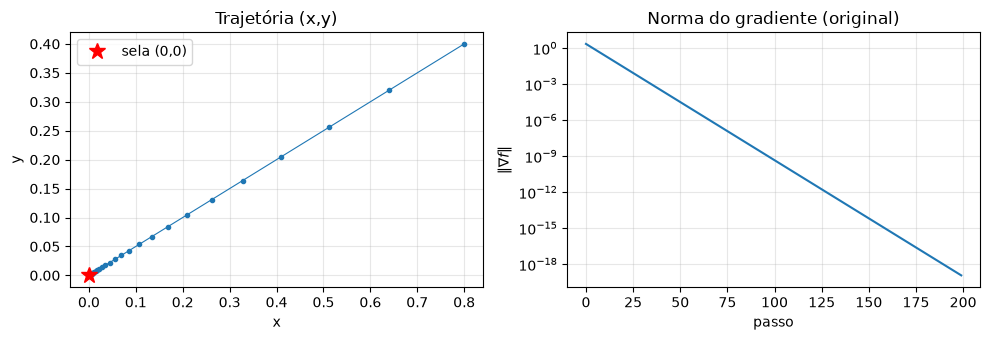

[OK] Dinâmica Morse-guided validada em f(x,y) = x^2 - y^2.


In [62]:
def check_72():
    # ============================================================
    # §8.2 — Teste da dinâmica Morse-guided em f(x,y) = x^2 - y^2
    # ============================================================
    # Hessiana de f = diag(2, -2) em todo ponto.
    # Autovetor instável: e_2 = (0,1), autovalor -2.
    # P_- = [[0,0],[0,1]].
    # Dinâmica: theta <- theta - eta * (I - 2P_-) grad f.
    # Em x: grad = 2x, não invertido -> converge para 0.
    # Em y: grad = -2y, invertido -> -grad = +2y -> sobe para 0 (sela).
    # Esperado: theta -> (0, 0).
    # ============================================================

    def f_saddle(theta):
        return theta[0]**2 - theta[1]**2

    def grad_f_saddle(theta):
        return torch.tensor([2*theta[0], -2*theta[1]], dtype=DTYPE)

    def hessian_eig_saddle(theta):
        H = np.array([[2.0, 0.0], [0.0, -2.0]])
        vals, vecs = np.linalg.eigh(H)
        return vals, vecs


    def run_saddle_demo(theta0, eta=0.1, steps=200, k=1):
        """Roda dinâmica Morse-guided em f(x,y) = x^2 - y^2."""
        theta = theta0.clone()
        hist = {"theta": [], "f": [], "grad": []}
        for step in range(steps):
            g = grad_f_saddle(theta)
            vals, vecs = hessian_eig_saddle(theta)
            idx = np.argsort(vals)[:k]
            V = vecs[:, idx]
            P = V @ V.T
            g_mod = g.numpy() - 2.0 * (P @ g.numpy())
            g_mod = torch.tensor(g_mod, dtype=DTYPE)
            theta = theta - eta * g_mod
            hist["theta"].append(theta.clone())
            hist["f"].append(f_saddle(theta).item())
            hist["grad"].append(g.norm().item())
        return theta, hist


    print("=== §8.2 Teste da dinâmica Morse-guided em f(x,y) = x^2 - y^2 ===\n")

    theta0 = torch.tensor([1.0, 0.5], dtype=DTYPE)
    theta_final, hist = run_saddle_demo(theta0, eta=0.1, steps=200, k=1)

    print(f"theta0      = {theta0.tolist()}")
    print(f"theta_final = {theta_final.tolist()}")
    print(f"f(theta0)   = {f_saddle(theta0).item():+.6e}")
    print(f"f(theta_f)  = {f_saddle(theta_final).item():+.6e}")
    print(f"esperado: theta -> (0,0), f -> 0\n")

    # Curva de convergência
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    thetas = torch.stack(hist["theta"]).numpy()
    axes[0].plot(thetas[:, 0], thetas[:, 1], "o-", ms=3, lw=0.8)
    axes[0].plot(0, 0, "r*", ms=12, label="sela (0,0)")
    axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
    axes[0].set_title("Trajetória (x,y)")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].semilogy(hist["grad"])
    axes[1].set_xlabel("passo"); axes[1].set_ylabel(r"$\|\nabla f\|$")
    axes[1].set_title("Norma do gradiente (original)")
    axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    assert abs(theta_final[0].item()) < 1e-3, "x não convergiu para 0"
    assert abs(theta_final[1].item()) < 1e-3, "y não convergiu para 0"
    print("[OK] Dinâmica Morse-guided validada em f(x,y) = x^2 - y^2.")

if RUN_ALL or RUN["checks"]:check_72()

In [63]:
if RUN_ALL or RUN['checks']:
    torch.manual_seed(SEED);m=TorusMLP(eps=.001)
    p=sum(x.numel() for x in m.parameters());v1=torch.randn(p,dtype=DTYPE);v2=torch.randn(p,dtype=DTYPE)
    symmetry=float(abs(v1@hvp(m,v2)-v2@hvp(m,v1)));assert symmetry<1e-7
    P,values,V=build_P_minus(m,k=3)
    assert float((P@P-P).abs().max())<1e-8
    assert float((P-P.T).abs().max())<1e-8
    assert np.max(abs(V.T@V-np.eye(3)))<1e-8
    print('HVP symmetry error',symmetry,'selected eigenvalues',values)

HVP symmetry error 2.220446049250313e-15 selected eigenvalues [-1.66926453e+01 -7.74236429e-03 -7.61099332e-03]


## 8. Plotting helpers

In [64]:
def show_table(df,cols=None):
    if df.empty:print('No matching runs available. Enable the block in RUN and rerun its cell.');return
    display(df[cols] if cols else df)

def result_for_row(row):
    return load_result(configuration({k:row[k] for k in DEFAULT}))

def plot_histories(df,name):
    if df.empty:return
    fig,axes=plt.subplots(1,4,figsize=(15,3.3))
    for _,row in df.iterrows():
        r=result_for_row(row);label=f"k={row.k}, eps={row.eps:g}, lambda={row.lam:g}, seed={row.seed}"
        axes[0].plot(r['A'],label=label);axes[1].semilogy(np.maximum(r['grad'],1e-16),label=label)
        axes[2].semilogy(np.maximum(r['det'],1e-16),label=label)
        if 'R' in r:axes[3].plot(r['R'],label=label)
    axes[0].axhline(A_CLIFF,color='k',ls='--');axes[1].axhline(1e-3,color='k',ls='--');axes[2].axhline(1e-6,color='k',ls='--')
    for ax,title in zip(axes,['Area','Area gradient norm','Minimum determinant','Penalty']):
        ax.set_title(title);ax.set_xlabel('Iteration');ax.legend(fontsize=6);ax.grid(alpha=.2)
    fig.tight_layout();fig.savefig(FIGS/(name+'.png'),dpi=180);plt.show()

def plot_views(df,name):
    if df.empty:return
    fig=plt.figure(figsize=(4*len(df),4.5))
    for i,(_,row) in enumerate(df.iterrows()):
        r=result_for_row(row)
        with torch.no_grad():X=r['model'].forward_uv(U0,V0).reshape(-1,4).numpy()
        den=1-X[:,3:4];Y=X[:,:3]/np.where(abs(den)<1e-8,np.nan,den)
        ax=fig.add_subplot(1,len(df),i+1,projection='3d');ax.scatter(*Y.T,s=2,alpha=.5)
        ax.set_title(f"{row['mode']}, k={row.k}\nA={row.area:.3f}\nsteps={row.steps}, eps={row.eps:g}")
        ax.set_box_aspect((1,1,1));ax.set_xticks([]);ax.set_yticks([]);ax.set_zticks([])
    fig.tight_layout();fig.savefig(FIGS/(name+'.png'),dpi=200);plt.show()

METRIC_COLS=['a0','b0','seed','k','eps','lam','steps','area','grad_tail','H_L2','min_det','status']

## Finish the submission experiments without resetting the session
The saved outputs show a completed demonstration and one accepted asymmetric candidate, but incomplete controlled and map families. Execute the cell below, then run every cell from section 9 through the end **in order**. Keep the existing `complete_results` directory and working directory. Matching completed runs will load; missing runs will train. This does not change numerical definitions or their cache fingerprint.

This selects the central report experiments plus all map families. Expensive optional extensions (penalty-only repair, extra Hessian states, long directed tests and exploratory k refinements) remain individually selectable. The report must be checked against the newly generated tables before submission.


In [ ]:
# Run this cell, then run section 9 and every subsequent cell in order.
RUN_ALL=False
submission_families=(
    'checks','demo','baseline','eps_ablation','pure_long','penalty',
    'equivalence','robust','paired58','spectral','representation','budget',
    'angular','coarse','frontier','transition','dense','anomalies',
)
RUN.update({family:True for family in submission_families})
print('Submission families enabled:',[family for family,enabled in RUN.items() if enabled])
print('Next: run section 9 through the final audit in order. Existing matching checkpoints are reused.')


## 9. Pure descent: three initializations

baseline: 1/3 available; 2 not trained


,a0,b0,seed,k,eps,lam,steps,area,grad_tail,H_L2,min_det,status
0,0.9,0.4,20260916,0,0.08,0.0,150,0.044469,4.556429,None,1.994819e-10,DEGENERATE


/tmp/ipykernel_22334/648462214.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_title(title);ax.set_xlabel('Iteration');ax.legend(fontsize=6);ax.grid(alpha=.2)


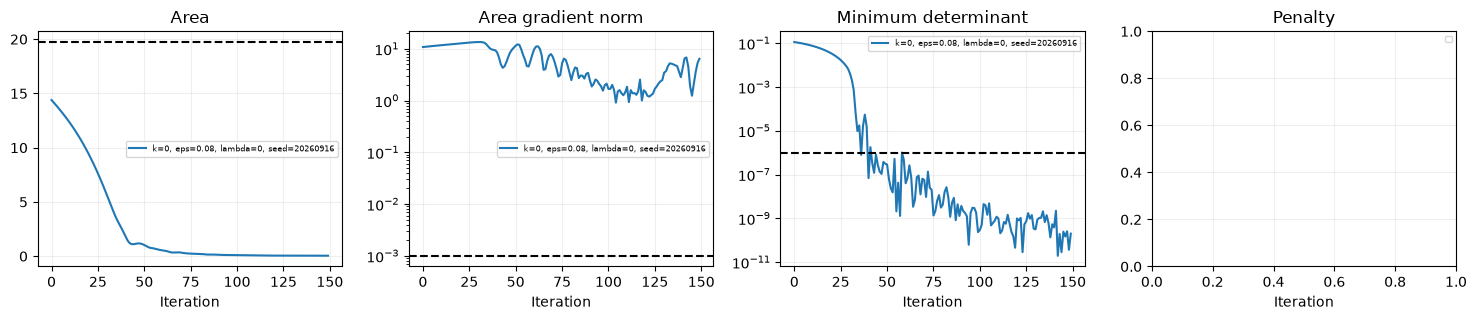

In [65]:
baseline=run_group("baseline")
show_table(baseline,METRIC_COLS)
plot_histories(baseline,"baseline")

### 9.1 Local rank, spatial masks, quantiles and angular conditioning
Norms and angle must be compared at the same minimum-determinant point. Separate minima may occur at different grid points.

,percentile,det,norm_Xu,norm_Xv,sin_angle
0,0,1.994819e-10,0.935475,0.000539,0.000392
1,1,1.328732e-08,0.939823,0.001229,0.003526
2,5,9.431652e-08,0.947257,0.002439,0.008602
3,10,2.074931e-07,0.954469,0.004507,0.012771
4,25,5.060477e-07,0.971493,0.010930,0.021868
5,50,1.089031e-06,0.997559,0.023719,0.043015
6,75,2.110058e-06,1.029855,0.042629,0.094760
7,90,3.527854e-06,1.047318,0.069895,0.236622
8,99,8.901918e-06,1.067188,0.110363,0.952055
9,100,1.703071e-05,1.072250,0.121736,0.999133


,a0,b0,global48_a,global48_b,global48_base_ratio,global48_max_P_over_B,global48_min_norm_F,global48_min_norm_Xu,global48_min_norm_Xv,global48_min_sin_angle,...,v,min_det_g,norm_Xu_at_min,norm_Xv_at_min,sin_angle_at_min,norm_F_at_min,P_over_B_at_min,n_bad,n_total,bad_fraction
0,0.9,0.4,0.988461,0.353384,0.357509,0.35711,0.946663,0.935475,0.000539,0.000392,...,3.141593,1.994819e-10,1.004682,0.017614,0.000798,1.013536,0.353859,1080,2304,0.468750
1,0.9,0.4,0.988461,0.353384,0.357509,0.35711,0.946663,0.935475,0.000539,0.000392,...,3.141593,1.042429e-10,1.007151,0.019887,0.000510,1.010427,0.353540,4328,9216,0.469618


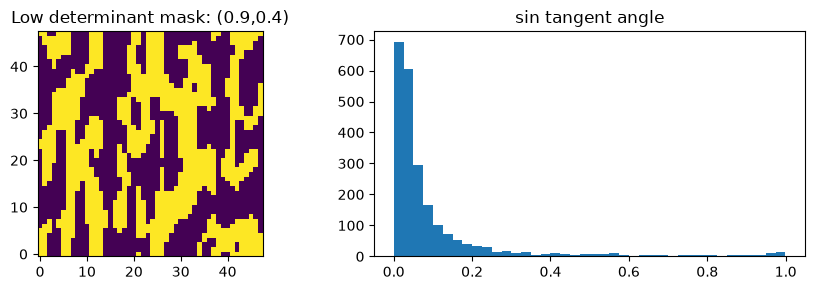

In [66]:
if not baseline.empty:
    diag_rows=[];fig,axes=plt.subplots(len(baseline),2,figsize=(9,3*len(baseline)),squeeze=False)
    for j,(_,row) in enumerate(baseline.iterrows()):
        m=result_for_row(row)['model'];d=degeneracy_diagnostics(m)
        global_diagnostics = {
            f"global48_{key}": value for key, value in d.items()
        }
        for N in (48, 96):
            local = local_rank_diagnostics(m, n_u=N, n_v=N)
            diag_rows.append(
                dict(a0=row.a0, b0=row.b0, **global_diagnostics, **local)
            )
            _,Xu,Xv,E,F,G,D=geometry(m);angle=(D.clamp_min(0)/(E*G).clamp_min(1e-30)).sqrt()
        axes[j,0].imshow((D.detach().numpy()<1e-6),origin='lower');axes[j,0].set_title(f'Low determinant mask: ({row.a0},{row.b0})')
        axes[j,1].hist(angle.detach().numpy().ravel(),bins=40);axes[j,1].set_title('sin tangent angle')
        q=np.array([0,1,5,10,25,50,75,90,99,100])
        display(pd.DataFrame({'percentile':q,'det':np.percentile(D.detach().numpy(),q),'norm_Xu':np.percentile(Xu.detach().norm(dim=-1).numpy(),q),'norm_Xv':np.percentile(Xv.detach().norm(dim=-1).numpy(),q),'sin_angle':np.percentile(angle.detach().numpy(),q)}))
    pd.DataFrame(diag_rows).to_csv(TABLES/'baseline_rank_diagnostics.csv',index=False)
    display(pd.DataFrame(diag_rows));fig.tight_layout();fig.savefig(FIGS/'rank_conditioning.png',dpi=180);plt.show()

## 10. Epsilon ablation and 2000-step pure descent
All epsilon-ablation runs use the same start/seed, 500 steps. The 2000-step run is a fresh start, not a continuation of the 500-step optimizer.

In [67]:
eps_ablation=run_group('eps_ablation');pure_long=run_group('pure_long')
show_table(eps_ablation,METRIC_COLS);show_table(pure_long,METRIC_COLS)
plot_histories(eps_ablation,'epsilon_ablation')
if not eps_ablation.empty:
    display(pd.DataFrame([dict(eps=row.eps,**degeneracy_diagnostics(result_for_row(row)['model'])) for _,row in eps_ablation.iterrows()]))
    small=eps_ablation[np.isclose(eps_ablation.eps,.001)]
    if not small.empty:
        m=result_for_row(small.iloc[0])['model'];*_,D=geometry(m)
        d=D.detach().numpy().ravel();positive=d[d>0]
        print('epsilon=0.001 determinant quantiles:',np.percentile(d,[0,1,5,25,50,75,95,99,100]))
        print('Grid fraction below 1e-6:',float((d<1e-6).mean()))
        fig,ax=plt.subplots(figsize=(5,3));ax.hist(np.log10(positive),bins=50);ax.axvline(-6,color='k',ls='--');ax.set_xlabel('log10 determinant');ax.set_ylabel('Grid points');fig.tight_layout();fig.savefig(FIGS/'small_epsilon_det_distribution.png',dpi=180);plt.show()


eps_ablation: 0/3 available; 3 not trained
pure_long: 0/1 available; 1 not trained
No matching runs available. Enable the block in RUN and rerun its cell.
No matching runs available. Enable the block in RUN and rerun its cell.


## 11. Lambda ablation and penalty-only repair
The ablation uses the central threshold 1e-6. The independent repair test starts from the collapsed pure-descent model, minimizes only R for 1000 steps, and explicitly uses tau=1e-2. Its threshold differs from the main comparison.

In [68]:
penalty=run_group('penalty');show_table(penalty,METRIC_COLS);plot_histories(penalty,'lambda_ablation')
if RUN_ALL or RUN['penalty_repair']:
    execute_run(BASELINE[0],allow_train=True)
    cfg=configuration(BASELINE[0])
    repair_key=hashlib.sha256(json.dumps(dict(initial_run=run_id(cfg),tau=1e-2,steps=1000,lr=.001,implementation=IMPLEMENTATION),sort_keys=True).encode()).hexdigest()[:20]
    repair_json=CACHE/f'repair_{repair_key}.json';repair_pt=CACHE/f'repair_{repair_key}.pt'
    if repair_json.exists() and repair_pt.exists():
        repair=json.loads(repair_json.read_text());print('Loaded penalty-only repair',repair)
    else:
        m=copy.deepcopy(load_result(cfg)['model'])
        before=float(regularity_penalty(m,tau_reg=1e-2));det_before=float(area_and_det(m)[1].min())
        opt=torch.optim.Adam(m.parameters(),lr=1e-3);start=time.time();repair_history=[]
        for _ in range(1000):
            opt.zero_grad(set_to_none=True);loss=regularity_penalty(m,tau_reg=1e-2,create_graph=True);loss.backward();opt.step()
            repair_history.append(float(regularity_penalty(m,tau_reg=1e-2)))
        after=float(regularity_penalty(m,tau_reg=1e-2));det_after=float(area_and_det(m)[1].min())
        repair=dict(initial_run=run_id(cfg),tau=1e-2,steps=1000,lr=.001,penalty_before=before,penalty_after=after,det_before=det_before,det_after=det_after,seconds=time.time()-start)
        assert after<before
        torch.save(dict(model_state=m.state_dict(),optimizer_state=opt.state_dict(),history=repair_history,settings=repair),repair_pt)
        repair_json.write_text(json.dumps(repair,indent=2))
    (TABLES/'penalty_repair.json').write_text(json.dumps(repair,indent=2));print(repair)


penalty: 0/4 available; 4 not trained
No matching runs available. Enable the block in RUN and rerun its cell.


### 11.1 Parameter-Hessian spectra: initial, collapsed and penalized states
Eight smallest eigenpairs are counted at these states. Negative eigenvalues away from a critical point do not certify a saddle critical point. This diagnostic is controlled by `RUN["hessian_states"]`.

In [69]:
hessian_states=run_group('hessian_states')
if RUN_ALL or RUN['hessian_states']:
    torch.manual_seed(SEED);initial_model=TorusMLP(a0=.9,b0=.4,eps=.001)
    models=[('initial',initial_model)]+[(row['mode'],result_for_row(row)['model']) for _,row in hessian_states.iterrows()]
    eig_rows=[]
    for label,m in models:
        vals,_=smallest_eigenpairs(m,k=8)
        eig_rows.append(dict(state=label,negative_among_eight=int((vals<0).sum()),eigenvalues=vals.tolist()))
    display(pd.DataFrame(eig_rows));(TABLES/'parameter_hessian_states.json').write_text(json.dumps(eig_rows,indent=2))


hessian_states: 1/2 available; 1 not trained


## 12. k=0 equivalence and four illustrative surfaces
Pure descent uses 150 steps, epsilon=0.08; other visual runs use 500 steps, epsilon=0.001. The visual comparison updates projectors every 25 steps. It is distinct from the controlled 165-run protocol. Every 3D axis is independently scaled.

equivalence: 1/2 available; 1 not trained


,a0,b0,seed,k,eps,lam,steps,area,grad_tail,H_L2,min_det,status
0,0.9,0.4,20260916,0,0.001,0.01,500,2.435444,3.377364,1869.373818,0.000001,NOT_STATIONARY


Training {'mode': 'reflected', 'seed': 20260916, 'a0': 0.9, 'b0': 0.4, 'k': 1, 'lam': 0.01, 'eps': 0.001, 'steps': 500, 'lr': 0.003, 'tau_reg': 1e-06, 'recompute_every': 25, 'width': 32, 'depth': 2}
  step 0: mu = [-2.4523]
  step 25: mu = [-2.7305]
  step 50: mu = [-3.1559]
  step 75: mu = [-3.9363]
  step 100: mu = [-5.5057]
  step 125: mu = [-8.383]
  step 150: mu = [-12.1147]
  step 175: mu = [-15.5717]
  step 200: mu = [-18.0621]
  step 225: mu = [-19.5407]
  step 250: mu = [-20.2984]
  step 275: mu = [-20.6496]
  step 300: mu = [-20.8041]
  step 325: mu = [-20.8716]
  step 350: mu = [-20.9014]
  step 375: mu = [-20.9147]
  step 400: mu = [-20.9205]
  step 425: mu = [-20.923]
  step 450: mu = [-20.9241]
  step 475: mu = [-20.9245]
Training {'mode': 'reflected', 'seed': 20260916, 'a0': 0.9, 'b0': 0.4, 'k': 5, 'lam': 0.01, 'eps': 0.001, 'steps': 500, 'lr': 0.003, 'tau_reg': 1e-06, 'recompute_every': 25, 'width': 32, 'depth': 2}
  step 0: mu = [-2.4523 -0.0211 -0.0209 -0.0206 -0.0206

,a0,b0,seed,k,eps,lam,steps,area,grad_tail,H_L2,min_det,status
0,0.90,0.40,20260916,0,0.080,0.00,150,0.044469,4.556429,NaN,1.994819e-10,DEGENERATE
1,0.90,0.40,20260916,0,0.001,0.01,500,2.435444,3.377364,1869.373818,1.029807e-06,NOT_STATIONARY
2,0.90,0.40,20260916,1,0.001,0.01,500,19.739339,0.000997,0.054910,2.358417e-01,NOT_APPROXIMATELY_MINIMAL
3,0.90,0.40,20260916,5,0.001,0.01,500,19.739481,0.001101,0.061294,2.361410e-01,NOT_STATIONARY
4,0.55,0.85,20260917,5,0.001,0.01,500,19.739213,0.000063,0.005907,2.471215e-01,CLIFFORD_COMPATIBLE


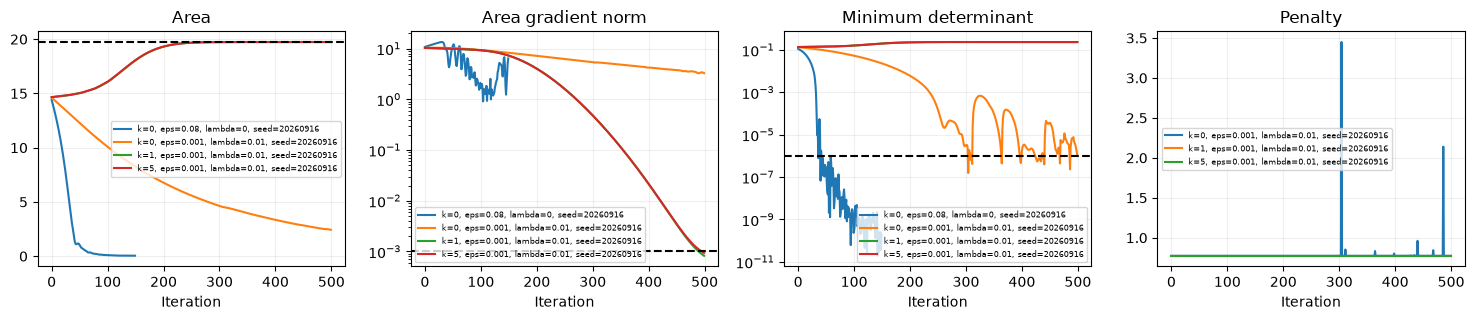

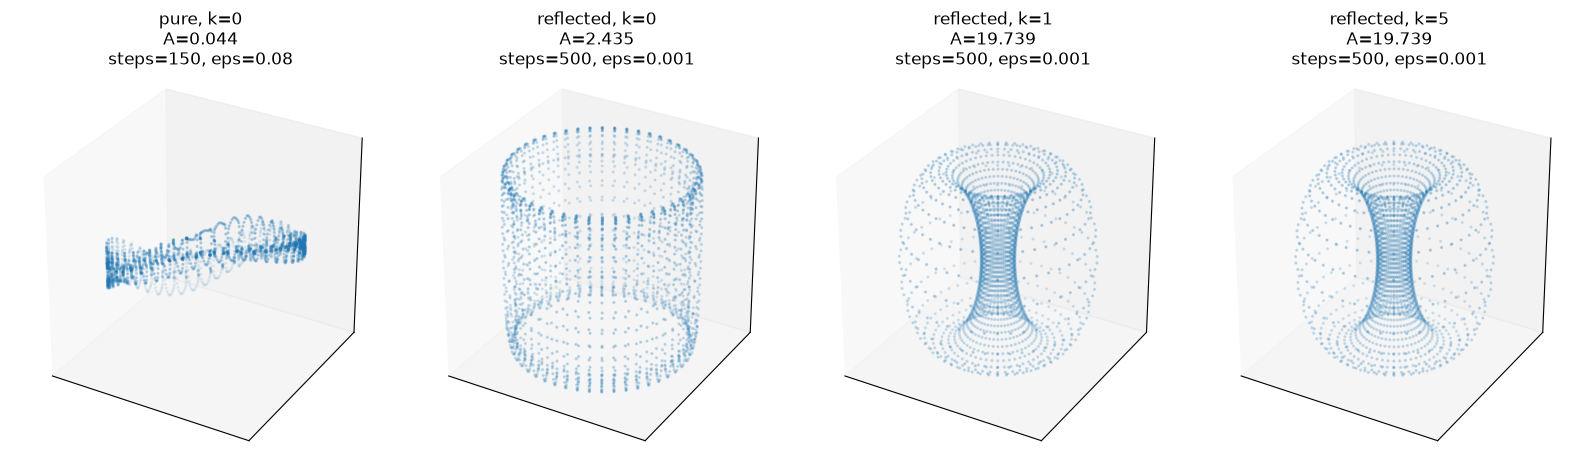

In [70]:
equivalence=run_group('equivalence');show_table(equivalence,METRIC_COLS)
if len(equivalence)==2:
    results=[result_for_row(row) for _,row in equivalence.iterrows()]
    for key in ('A','grad','det','R'):
        err=float(np.max(abs(results[0][key]-results[1][key])));print(key,'max absolute difference',err)
        assert np.allclose(results[0][key],results[1][key],rtol=1e-8,atol=1e-10)
demo=run_group('demo');show_table(demo,METRIC_COLS)
plot_histories(demo.iloc[:4],'method_comparison');plot_views(demo.iloc[:4],'torus_comparison')

## 13. Fine convergence and single-start k sweep
1000 steps and projector updates every 100 steps. Historical minimum gradients are displayed alongside final/tail gradients; historical minima do not determine final acceptance.

In [71]:
fine=run_group('fine');exploratory_k=run_group('exploratory_k')
show_table(fine,METRIC_COLS);plot_histories(fine,'fine_convergence')
show_table(exploratory_k,['k','area','area_error','grad_min','grad_final','grad_tail','min_det','H_L2','status','seconds'])
if not exploratory_k.empty:
    fig,axes=plt.subplots(1,3,figsize=(12,3.3))
    for ax,col in zip(axes,['area_error','grad_min','min_det']):ax.semilogy(exploratory_k.k,exploratory_k[col],'o-');ax.set_xlabel('k');ax.set_ylabel(col);ax.grid(alpha=.2)
    fig.tight_layout();fig.savefig(FIGS/'exploratory_k.png',dpi=180);plt.show()
if not fine.empty:
    fig,ax=plt.subplots(figsize=(5,3))
    for _,row in fine.iterrows():
        eig=result_for_row(row).get('eig',[])
        if eig:ax.plot([s for s,v in eig],[v[0] for s,v in eig],'o-',label=f'k={row.k}')
    ax.set_xlabel('Iteration');ax.set_ylabel('Smallest parameter-Hessian eigenvalue');ax.legend();fig.tight_layout();fig.savefig(FIGS/'hessian_evolution.png',dpi=180);plt.show()

fine: 0/2 available; 2 not trained
exploratory_k: 0/8 available; 8 not trained
No matching runs available. Enable the block in RUN and rerun its cell.
No matching runs available. Enable the block in RUN and rerun its cell.


## 14. Controlled robustness: all k=0,…,10, five starts and three seeds
165 configurations; 500 steps and projector recomputation every 50. Positive controls have equal base radii. The candidate classification is final-state based.

robust: 1/165 available; 164 not trained


,,runs,accepted,median_seconds,median_H_accepted
k,group,,,,
5,asymmetric,1,1,127.940666,0.005907


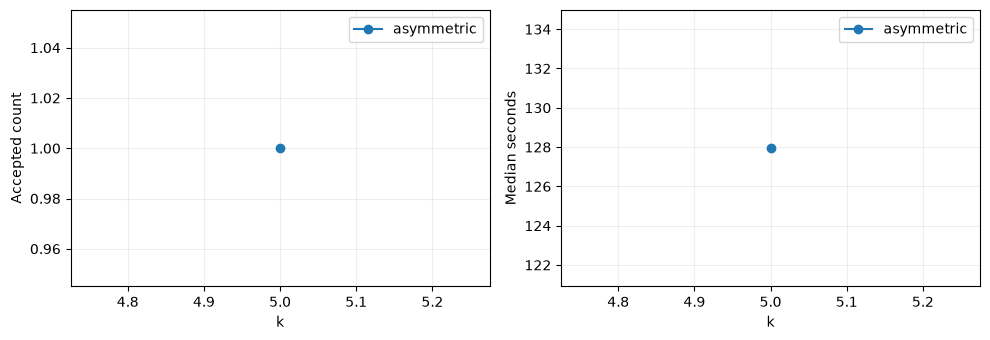

In [72]:
robust=run_group('robust')
if not robust.empty:
    robust['group']=np.where(np.isclose(robust.a0,robust.b0),'symmetric','asymmetric')
    table=robust.groupby(['k','group']).agg(runs=('accepted','size'),accepted=('accepted','sum'),median_seconds=('seconds','median'))
    accepted_H=robust[robust.accepted].groupby(['k','group']).H_L2.median().rename('median_H_accepted')
    table=table.join(accepted_H);display(table);table.to_csv(TABLES/'robust_summary.csv')
    fig,axes=plt.subplots(1,2,figsize=(10,3.5))
    for group,sub in robust.groupby('group'):
        stats=sub.groupby('k').agg(success=('accepted','sum'),seconds=('seconds','median'))
        axes[0].plot(stats.index,stats.success,'o-',label=group);axes[1].plot(stats.index,stats.seconds,'o-',label=group)
    axes[0].set_ylabel('Accepted count');axes[1].set_ylabel('Median seconds')
    for ax in axes:ax.set_xlabel('k');ax.legend();ax.grid(alpha=.2)
    fig.tight_layout();fig.savefig(FIGS/'robust_k.png',dpi=180);plt.show()

## 15. Paired k=5 versus k=8
Exactly the same 15 starts/seeds, 500 steps and recomputation every 50. Counts and costs are calculated from the same recorded family.

In [73]:
paired58=run_group('paired58')
if not paired58.empty:
    display(paired58.pivot(index=['a0','b0','seed'],columns='k',values='status'))
    paired_summary=paired58.groupby('k').agg(runs=('accepted','size'),accepted=('accepted','sum'),median_seconds=('seconds','median'),total_seconds=('seconds','sum'))
    paired_summary['seconds_per_success']=paired_summary.total_seconds/paired_summary.accepted.replace(0,np.nan)
    display(paired_summary);paired_summary.to_csv(TABLES/'paired58_summary.csv')

paired58: 1/30 available; 29 not trained


,,k,5
a0,b0,seed,
0.55,0.85,20260917,CLIFFORD_COMPATIBLE


,runs,accepted,median_seconds,total_seconds,seconds_per_success
k,,,,,
5,1,1,127.940666,127.940666,127.940666


## 16. Directed difficult-start extension
Six longer runs at (0.90,0.40), and twelve threshold comparisons at (0.95,0.20). These are additional tests, not assumed results. Enable `targeted_extension` or use the complete profile. Their outcomes are calculated when executed.


In [74]:
targeted_extension=run_group("targeted_extension")
show_table(targeted_extension,METRIC_COLS+["tau_reg"])

targeted_extension: 0/18 available; 18 not trained
No matching runs available. Enable the block in RUN and rerun its cell.


## 17. Independent Jacobi operator
The finite-difference stencil and arithmetic symmetrization are retained for traceability. The matrix called L discretizes minus the Laplacian. For variable metrics this stencil/symmetrization is approximate; numerical index counts are diagnostics. Asymmetry and eigenpair residuals are reported. Normal-vector orientation need not be continuous for computing the squared second fundamental form, but finite precision still matters.

In [75]:
def build_laplacian_matrix(X, U, V, det_g, E, F, G):
    N_U, N_V = det_g.shape
    N = N_U * N_V
    du = 2 * np.pi / N_U
    dv = 2 * np.pi / N_V
    det_g_np = det_g.detach().cpu().numpy()
    E_np = E.detach().cpu().numpy()
    F_np = F.detach().cpu().numpy()
    G_np = G.detach().cpu().numpy()
    sqrt_g = np.sqrt(np.clip(det_g_np, 1e-30, None))
    g_inv_uu = G_np / det_g_np
    g_inv_uv = -F_np / det_g_np
    g_inv_vv = E_np / det_g_np
    rows, cols, data = ([], [], [])

    def idx(i, j):
        return i % N_U * N_V + j % N_V
    for i in range(N_U):
        for j in range(N_V):
            row = idx(i, j)
            ip, im = ((i + 1) % N_U, (i - 1) % N_U)
            jp, jm = ((j + 1) % N_V, (j - 1) % N_V)

            def sguu(i, j):
                return sqrt_g[i, j] * g_inv_uu[i, j]

            def sguv(i, j):
                return sqrt_g[i, j] * g_inv_uv[i, j]

            def sgvv(i, j):
                return sqrt_g[i, j] * g_inv_vv[i, j]
            inv_sqrt_g = 1.0 / sqrt_g[i, j]
            c_ii = inv_sqrt_g * (sguu(i, j) + sguu(im, j)) / du ** 2
            c_ip = -inv_sqrt_g * sguu(i, j) / du ** 2
            c_im = -inv_sqrt_g * sguu(im, j) / du ** 2
            c_jj_vv = inv_sqrt_g * (sgvv(i, j) + sgvv(i, jm)) / dv ** 2
            c_jp = -inv_sqrt_g * sgvv(i, j) / dv ** 2
            c_jm = -inv_sqrt_g * sgvv(i, jm) / dv ** 2
            c_ip_jp = -inv_sqrt_g * sguv(i, j) / (4 * du * dv)
            c_ip_jm = +inv_sqrt_g * sguv(i, j) / (4 * du * dv)
            c_im_jp = +inv_sqrt_g * sguv(i, j) / (4 * du * dv)
            c_im_jm = -inv_sqrt_g * sguv(i, j) / (4 * du * dv)
            c_ip_jp += -inv_sqrt_g * sguv(i, j) / (4 * du * dv)
            c_ip_jm += +inv_sqrt_g * sguv(i, j) / (4 * du * dv)
            c_im_jp += +inv_sqrt_g * sguv(i, j) / (4 * du * dv)
            c_im_jm += -inv_sqrt_g * sguv(i, j) / (4 * du * dv)
            rows += [row] * 6
            cols += [idx(i, j), idx(ip, j), idx(im, j), idx(i, jp), idx(i, jm), idx(i, j)]
            data += [c_ii + c_jj_vv, c_ip, c_im, c_jp, c_jm, 0.0]
            rows += [row] * 4
            cols += [idx(ip, jp), idx(ip, jm), idx(im, jp), idx(im, jm)]
            data += [c_ip_jp, c_ip_jm, c_im_jp, c_im_jm]
    L = csr_matrix((data, (rows, cols)), shape=(N, N))
    return L

def normal_vector(X, Xu, Xv):

    def normalize(v, eps=1e-12):
        n = v.norm(dim=-1, keepdim=True).clamp_min(eps)
        return v / n
    e1 = normalize(X)
    e2 = Xu - (Xu * e1).sum(-1, keepdim=True) * e1
    e2 = normalize(e2)
    e3 = Xv - (Xv * e1).sum(-1, keepdim=True) * e1 - (Xv * e2).sum(-1, keepdim=True) * e2
    e3 = normalize(e3)
    N = torch.zeros_like(X)
    for k in range(4):
        ek = torch.zeros_like(X)
        ek[..., k] = 1.0
        residual = ek.clone()
        residual = residual - (residual * e1).sum(-1, keepdim=True) * e1
        residual = residual - (residual * e2).sum(-1, keepdim=True) * e2
        residual = residual - (residual * e3).sum(-1, keepdim=True) * e3
        norm_res = residual.norm(dim=-1, keepdim=True)
        N = torch.where(norm_res > N.norm(dim=-1, keepdim=True), residual, N)
        N = normalize(N)
    return N

def second_fundamental_sq(X, Xu, Xv, Xuu, Xuv, Xvv, U=None, V=None):
    N_field = normal_vector(X, Xu, Xv)
    E = (Xu * Xu).sum(dim=-1)
    F = (Xu * Xv).sum(dim=-1)
    G = (Xv * Xv).sum(dim=-1)
    det_g = (E * G - F * F).clamp_min(1e-14)
    A_uu_vec = Xuu + E.unsqueeze(-1) * X
    A_uv_vec = Xuv + F.unsqueeze(-1) * X
    A_vv_vec = Xvv + G.unsqueeze(-1) * X
    A_uu = (A_uu_vec * N_field).sum(dim=-1)
    A_uv = (A_uv_vec * N_field).sum(dim=-1)
    A_vv = (A_vv_vec * N_field).sum(dim=-1)
    g_inv_uu = G / det_g
    g_inv_uv = -F / det_g
    g_inv_vv = E / det_g
    g_inv = torch.stack([torch.stack([g_inv_uu, g_inv_uv], dim=-1), torch.stack([g_inv_uv, g_inv_vv], dim=-1)], dim=-2)
    A_mat = torch.stack([torch.stack([A_uu, A_uv], dim=-1), torch.stack([A_uv, A_vv], dim=-1)], dim=-2)
    B = torch.matmul(g_inv, A_mat)
    A_sq = torch.einsum('...ij,...ji->...', B, B)
    return A_sq

def build_jacobi(X, U, V, det_g, E, F, G):
    Xu, Xv, Xuu, Xuv, Xvv = compute_second_derivatives(X, U, V)
    A_sq = second_fundamental_sq(X, Xu, Xv, Xuu, Xuv, Xvv, U, V)
    L = build_laplacian_matrix(X, U, V, det_g, E, F, G)
    N = det_g.shape[0] * det_g.shape[1]
    A_sq_np = A_sq.detach().cpu().numpy().reshape(-1)
    from scipy.sparse import diags, identity, csr_matrix
    J = L - diags(A_sq_np) - 2.0 * identity(N, format='csr')
    return J

def jacobi_matrix_for_model(model, N_U=48, N_V=48):
    u = torch.linspace(0.0, 2 * np.pi, N_U + 1, dtype=DTYPE, device=DEVICE)[:-1]
    v = torch.linspace(0.0, 2 * np.pi, N_V + 1, dtype=DTYPE, device=DEVICE)[:-1]
    U, V = torch.meshgrid(u, v, indexing='ij')
    U.requires_grad_(True)
    V.requires_grad_(True)
    X = model.forward_uv(U, V)
    Xu, Xv, Xuu, Xuv, Xvv = compute_second_derivatives(X, U, V)
    E = (Xu * Xu).sum(dim=-1)
    F = (Xu * Xv).sum(dim=-1)
    G = (Xv * Xv).sum(dim=-1)
    det_g = (E * G - F * F).clamp_min(1e-14)
    J = build_jacobi(X, U, V, det_g, E, F, G)
    diagnostics = {'min_det_g': det_g.min().item(), 'max_det_g': det_g.max().item(), 'mean_det_g': det_g.mean().item()}
    return (J, diagnostics)

In [76]:
def spectral_diagnostics(model,N):
    J,diag=jacobi_matrix_for_model(model,N_U=N,N_V=N)
    asym=np.linalg.norm((J-J.T).data)/max(np.linalg.norm(J.data),1e-14)
    Js=.5*(J+J.T)
    vals,vecs=eigsh(Js,k=15,which='SA',tol=1e-8,v0=np.random.default_rng(SEED).normal(size=Js.shape[0]))
    order=np.argsort(vals);vals=vals[order];vecs=vecs[:,order]
    tol=max(1e-3,.5*(2*np.pi/N)**2)
    residuals=[np.linalg.norm(Js@v-lam*v)/(np.linalg.norm(Js@v)+abs(lam)*np.linalg.norm(v)+1e-14) for lam,v in zip(vals,vecs.T)]
    row=dict(N=N,index=int((vals < -tol).sum()),nullity=int((abs(vals)<=tol).sum()),tol_zero=tol,asymmetry=asym,max_residual=max(residuals),H_L2=float(h_norm_l2(model,N,N)),**diag)
    return row,vals

### 17.1 Analytic Clifford: geometric controls and 24/48/96 refinement
The exact spectrum is 2(m²+n²)-4, with index 5 and nullity 4. Grid tolerance is max(1e-3,0.5h²).

In [77]:
spectral_rows=[];spectra={}
if RUN_ALL or RUN['spectral']:
    for N in SPECTRAL_GRIDS:
        row,vals=spectral_diagnostics(AnalyticClifford(),N);row['surface']='Analytic Clifford';spectral_rows.append(row);spectra[('Analytic Clifford',N)]=vals
        assert (row['index'],row['nullity'])==(5,4)
    display(pd.DataFrame(spectral_rows))

### 17.2 Candidates: symmetric control, asymmetric k=5 and asymmetric k=8
Select the smallest mean-curvature residual among the actually available accepted runs in each group. If none pass, report that fact rather than declaring a surface found. Compute refinement and spectral robustness for every available seed.

In [78]:
spectral_candidates=run_group('spectral')
selected={};seed_spectra=[]
if RUN_ALL or RUN['spectral']:
    for k,kind in [(5,'symmetric'),(5,'asymmetric'),(8,'asymmetric')]:
        sub=spectral_candidates[(spectral_candidates.k==k)&(np.isclose(spectral_candidates.a0,spectral_candidates.b0)==(kind=='symmetric'))]
        accepted=sub[sub.accepted]
        if accepted.empty:print('No accepted candidate:',kind,k);continue
        best=accepted.sort_values('H_L2').iloc[0];label=f'{kind} k={k}';selected[label]=best
        model=result_for_row(best)['model']
        for N in SPECTRAL_GRIDS:
            row,vals=spectral_diagnostics(model,N);row.update(surface=label,seed=int(best.seed));spectral_rows.append(row);spectra[(label,N)]=vals
        for _,candidate in accepted.iterrows():
            row,vals=spectral_diagnostics(result_for_row(candidate)['model'],48);row.update(surface=label,seed=int(candidate.seed));seed_spectra.append(row)
    pd.DataFrame(spectral_rows).to_csv(TABLES/'spectral_refinement.csv',index=False)
    pd.DataFrame(seed_spectra).to_csv(TABLES/'spectral_seed_robustness.csv',index=False)
    display(pd.DataFrame(spectral_rows));display(pd.DataFrame(seed_spectra))
    for (label,N),vals in spectra.items():np.save(OUT/f"spectrum_{label.replace(' ','_')}_{N}.npy",vals)

spectral: 1/9 available; 8 not trained


### 17.3 Near-zero cluster, residuals and Richardson extrapolation
Only use matching selected models across grids. Richardson assumes leading h² error; it is diagnostic and cannot remove residual nonminimality.

In [79]:
if spectra:
    fig,ax=plt.subplots(figsize=(7,4))
    for label in sorted({key[0] for key in spectra}):
        Ns=sorted(N for lab,N in spectra if lab==label)
        ax.plot(Ns,[spectra[(label,N)][5] for N in Ns],'o-',label=label)
        if all((label,N) in spectra for N in (48,96)):
            extrap=(4*spectra[(label,96)][5:9]-spectra[(label,48)][5:9])/3
            print(label,'Richardson near-zero cluster',extrap)
    ax.axhline(0,color='k',ls='--');ax.set_xlabel('Grid size');ax.set_ylabel('First near-zero eigenvalue (index 5)');ax.legend();fig.tight_layout();fig.savefig(FIGS/'near_zero_cluster.png',dpi=180);plt.show()

## 18. Base versus neural contribution on a 96x96 grid

In [80]:
representation=run_group('representation')
if not representation.empty:
    m=result_for_row(representation.iloc[0])['model']
    t=torch.linspace(0,2*np.pi,97,dtype=DTYPE,device=DEVICE)[:-1];U,V=torch.meshgrid(t,t,indexing='ij')
    with torch.no_grad():
        z=periodic_features(U,V);cu,su,cv,sv=z.unbind(-1)
        B=torch.stack([m.a*cu,m.a*su,m.b*cv,m.b*sv],-1);P=m.eps*m.net(z)
        X=(B+P)/(B+P).norm(dim=-1,keepdim=True).clamp_min(1e-12);Xbase=B/B.norm(dim=-1,keepdim=True)
        ratio=P.norm(dim=-1)/B.norm(dim=-1)
        decomposition=dict(a=float(m.a),b=float(m.b),a_over_b=float(m.a/m.b),relative_RMS=float(P.square().sum(-1).mean().sqrt()/B.square().sum(-1).mean().sqrt()),mean_pointwise_ratio=float(ratio.mean()),max_pointwise_ratio=float(ratio.max()),RMS_surface_difference=float((X-Xbase).square().sum(-1).mean().sqrt()),max_surface_difference=float((X-Xbase).norm(dim=-1).max()))
    print(decomposition);(TABLES/'representation.json').write_text(json.dumps(decomposition,indent=2))

representation: 1/1 available; 0 not trained
{'a': 0.677560841644717, 'b': 0.6829315926064643, 'a_over_b': 0.9921357409440535, 'relative_RMS': 0.005371674487290673, 'mean_pointwise_ratio': 0.0053470224567738955, 'max_pointwise_ratio': 0.006335395750742613, 'RMS_surface_difference': 0.004321277569939328, 'max_surface_difference': 0.006048914957833956}


## 19. Angular slice at radius one
Here delta is an angle: a0=cos(pi/4-delta), b0=sin(pi/4-delta). It is not the later absolute difference |a0-b0|.

In [81]:
angular=run_group('angular')
if not angular.empty:
    angular['angular_delta']=np.pi/4-np.arctan2(angular.b0,angular.a0)
    stats=angular.groupby('angular_delta').agg(n=('accepted','size'),success=('accepted','mean'),median_H=('H_L2','median'));display(stats)
    fig,axes=plt.subplots(1,2,figsize=(9,3.5));axes[0].plot(stats.index,stats.success,'o-');axes[1].semilogy(stats.index,stats.median_H,'o-')
    for ax in axes:ax.set_xlabel('Angular delta');ax.grid(alpha=.2)
    axes[0].set_ylabel('Accepted fraction');axes[1].set_ylabel('Median L2 curvature');fig.tight_layout();fig.savefig(FIGS/'angular_slice.png',dpi=180);plt.show()

angular: 0/21 available; 21 not trained


## 20. Coarse 5x5 map: 300 steps and one seed

In [82]:
coarse=run_group("coarse")
show_table(coarse,METRIC_COLS)

coarse: 0/25 available; 25 not trained
No matching runs available. Enable the block in RUN and rerun its cell.


## 21. Eight frontier points with two extra seeds; four transition points with three seeds
These all use 300 steps and recomputation every 100. Identical full configurations are reused; different budgets are not.

In [83]:
frontier=run_group("frontier")
transition=run_group("transition")
show_table(frontier,METRIC_COLS)
show_table(transition,METRIC_COLS)

frontier: 0/16 available; 16 not trained
transition: 0/12 available; 12 not trained
No matching runs available. Enable the block in RUN and rerun its cell.
No matching runs available. Enable the block in RUN and rerun its cell.


## 22. Five fresh-start budget comparisons: 500 versus 1000 steps
This is not continuation. Compare paired seed/configuration outcomes and curvature. A pair that passes at both budgets is not a rescued failure.

In [84]:
budget=run_group('budget')
if not budget.empty:
    display(budget.pivot(index=['a0','b0','seed'],columns='steps',values=['accepted','H_L2','grad_tail']))
    fig,ax=plt.subplots(figsize=(6,4))
    for (a,b,seed),sub in budget.groupby(['a0','b0','seed']):
        sub=sub.sort_values('steps');ax.semilogy(sub.steps,sub.H_L2,'o-',label=f'({a},{b}), {seed}')
    ax.axhline(.05,color='k',ls='--');ax.set_xlabel('Fresh training budget');ax.set_ylabel('L2 mean curvature');ax.legend(fontsize=7);fig.tight_layout();fig.savefig(FIGS/'budget_comparison.png',dpi=180);plt.show()

budget: 0/10 available; 10 not trained


## 23. Dense 9x9 map: 500 steps, one seed
Every configuration uses 500 steps. The map is generated here with a consistent budget. Compare it with the 300-step coarse map only with the budget difference explicitly stated.


In [85]:
dense=run_group("dense")
show_table(dense,METRIC_COLS)

dense: 0/81 available; 81 not trained
No matching runs available. Enable the block in RUN and rerun its cell.


## 24. Anomaly-point extra seeds
Extra seeds are tested at rounded points (0.619,0.338) and (0.713,0.525). These are not exactly the dense-grid coordinates. We retain them as separate configurations, avoiding a false pairing through rounding.

In [86]:
anomalies=run_group("anomalies")
show_table(anomalies,METRIC_COLS)

anomalies: 0/4 available; 4 not trained
No matching runs available. Enable the block in RUN and rerun its cell.


## 25. Map consolidation, heatmaps and probability contours
Deduplicate by complete run_id and keep budgets separate. Three-seed fractions are descriptive estimates. Contours interpolate sparsely sampled fractions and do not establish a deterministic convergence boundary.

In [87]:
map_frames=[df for df in [coarse,frontier,transition,budget,dense,anomalies] if not df.empty]
map_data=pd.concat(map_frames,ignore_index=True).drop_duplicates('run_id') if map_frames else pd.DataFrame()
if not map_data.empty:
    map_data['ratio']=map_data.b0/map_data.a0;map_data['radius']=np.hypot(map_data.a0,map_data.b0)
    map_data['abs_difference']=abs(map_data.a0-map_data.b0)
    map_data.to_csv(TABLES/'map_records_all_budgets.csv',index=False)
    display(map_data.groupby('steps').agg(records=('accepted','size'),accepted_fraction=('accepted','mean')))
    for steps,sub in map_data.groupby('steps'):
        agg=sub.groupby(['a0','b0']).agg(success=('accepted','mean'),n=('accepted','size'),H=('H_L2','median'),grad=('grad_tail','median')).reset_index()
        agg.to_csv(TABLES/f'map_points_steps{steps}.csv',index=False)
        fig,axes=plt.subplots(1,3,figsize=(13,4))
        for ax,col,title in zip(axes,['success','H','grad'],['Accepted fraction','Median curvature','Median tail gradient']):
            values=agg[col].to_numpy();values=np.log10(np.maximum(values,1e-16)) if col!='success' else values
            im=ax.scatter(agg.a0,agg.b0,c=values,s=90,marker='s',cmap='viridis');fig.colorbar(im,ax=ax)
            ax.set_xlabel('a0');ax.set_ylabel('b0');ax.set_title(title+(' (log10)' if col!='success' else ''))
        fig.suptitle(f'Budget={steps}; number of seeds varies by point');fig.tight_layout();fig.savefig(FIGS/f'map_steps{steps}.png',dpi=180);plt.show()
        if len(agg)>=6:
            from scipy.interpolate import griddata
            xx,yy=np.meshgrid(np.linspace(agg.a0.min(),agg.a0.max(),100),np.linspace(agg.b0.min(),agg.b0.max(),100))
            zz=griddata(agg[['a0','b0']].to_numpy(),agg.success.to_numpy(),(xx,yy),method='linear')
            if np.isfinite(zz).any() and np.nanmin(zz)<np.nanmax(zz):
                fig,ax=plt.subplots(figsize=(5,4));c=ax.contour(xx,yy,zz,levels=[.25,.5,.75]);ax.clabel(c);ax.scatter(agg.a0,agg.b0,c=agg.success,s=15,vmin=0,vmax=1)
                ax.set_xlabel('a0');ax.set_ylabel('b0');ax.set_title(f'Descriptive interpolated contours, {steps} steps');fig.tight_layout();fig.savefig(FIGS/f'contours_steps{steps}.png',dpi=180);plt.show()

## 26. Difference, ratio and scale: binning and corrected logistic analysis
Fit each budget separately, with predictor abs(a0-b0). Its midpoint cannot be exponentiated into a ratio interval. Accuracy is in-sample. The squared-error score is labelled correctly, not called a likelihood pseudo-R². Repeated/selected points and limited seeds restrict statistical interpretation. Wilson intervals describe bin fractions under an independence approximation; they do not remove within-point dependence.

In [88]:
def wilson_interval(success,n,z=1.96):
    p=success/n;den=1+z*z/n;center=(p+z*z/(2*n))/den;half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    return center-half,center+half

if not map_data.empty:
    from sklearn.linear_model import LogisticRegression
    for steps,sub in map_data.groupby('steps'):
        sub=sub.copy();sub['bin']=pd.cut(sub.abs_difference,[0,.05,.14,.23,.33,.42,.6,np.inf],include_lowest=True)
        bins=sub.groupby('bin',observed=True).agg(n=('accepted','size'),successes=('accepted','sum'),center=('abs_difference','mean'),median_H=('H_L2','median'))
        bins['fraction']=bins.successes/bins.n;interval=[wilson_interval(row.successes,row.n) for _,row in bins.iterrows()]
        bins['low']=[a for a,b in interval];bins['high']=[b for a,b in interval]
        display(bins);bins.to_csv(TABLES/f'difference_bins_{steps}.csv')
        for variable,edges in [('ratio',[0,.2,.4,.6,.8,1,1.25,1.6,2,3,np.inf]),('radius',[0,.4,.6,.8,1,1.2,1.4,np.inf])]:
            cuts=pd.cut(sub[variable],edges,include_lowest=True)
            table=sub.groupby(cuts,observed=True).agg(n=('accepted','size'),success=('accepted','mean'),median_H=('H_L2','median'))
            print(variable);display(table);table.to_csv(TABLES/f'{variable}_bins_{steps}.csv')
        if sub.accepted.nunique()<2:print('Logistic model skipped: one outcome class.');continue
        X=sub[['abs_difference']].to_numpy();y=sub.accepted.astype(int).to_numpy()
        model=LogisticRegression(C=np.inf,solver='lbfgs',max_iter=1000).fit(X,y)
        b0=float(model.intercept_[0]);b1=float(model.coef_[0,0]);prob=model.predict_proba(X)[:,1]
        midpoint=-b0/b1 if abs(b1)>1e-12 else None
        accuracy=float((model.predict(X)==y).mean())
        mse_skill=float(1-np.sum((y-prob)**2)/np.sum((y-y.mean())**2))
        record=dict(steps=int(steps),records=len(sub),intercept=b0,slope=b1,difference_midpoint=midpoint,in_sample_accuracy=accuracy,squared_error_skill=mse_skill)
        print(record);(TABLES/f'logistic_steps{steps}.json').write_text(json.dumps(record,indent=2))
        xx=np.linspace(0,max(sub.abs_difference.max(),.55),200);pp=1/(1+np.exp(-(b0+b1*xx)))
        fig,axes=plt.subplots(1,2,figsize=(10,4));axes[0].plot(xx,pp,label='Logistic fit');axes[0].errorbar(bins.center,bins.fraction,yerr=np.vstack([bins.fraction-bins.low,bins.high-bins.fraction]),fmt='o',capsize=3,label='Binned fractions')
        axes[0].set_ylim(0,1);axes[0].set_ylabel('Accepted fraction');axes[0].legend()
        axes[1].semilogy(bins.center,bins.median_H,'o-');axes[1].axhline(.05,color='k',ls='--');axes[1].set_ylabel('Median L2 curvature')
        for ax in axes:ax.set_xlabel('|a0-b0|');ax.grid(alpha=.2)
        fig.suptitle(f'Budget {steps}: descriptive, not held-out validation');fig.tight_layout();fig.savefig(FIGS/f'logistic_steps{steps}.png',dpi=180);plt.show()

### 26.1 Gaussian-smoothed success map and empirical band
For each iteration budget, average accepted outcomes by initialization point before Gaussian smoothing. The colors describe observed acceptance locally, not a theorem or the acceptance rule. The bandwidth is in radius-coordinate units. Point size shows seed count. The dashed band uses the logistic midpoint fitted for this budget when it is positive and finite; it is never fixed to the value in a historical plot. Areas outside the sampled convex hull are masked. Run the map families before interpreting this figure.


In [89]:
if not map_data.empty:
    from scipy.spatial import Delaunay, QhullError
    sigma=0.10
    for steps,sub in map_data.groupby('steps'):
        points=sub.groupby(['a0','b0']).agg(fraction=('accepted','mean'),n=('accepted','size')).reset_index()
        xy=points[['a0','b0']].to_numpy()
        if len(xy)<3 or np.linalg.matrix_rank(xy-xy.mean(axis=0))<2:
            print('Kernel map skipped: insufficient two-dimensional support.',steps)
            continue
        xx,yy=np.meshgrid(np.linspace(xy[:,0].min(),xy[:,0].max(),160),
                          np.linspace(xy[:,1].min(),xy[:,1].max(),160))
        grid=np.column_stack([xx.ravel(),yy.ravel()])
        weights=np.exp(-((grid[:,None,:]-xy[None,:,:])**2).sum(axis=2)/(2*sigma**2))
        smooth=(weights@points.fraction.to_numpy())/weights.sum(axis=1)
        try:
            smooth[Delaunay(xy).find_simplex(grid)<0]=np.nan
        except QhullError:
            print('Kernel map skipped: convex-hull construction failed.',steps)
            continue
        fig,ax=plt.subplots(figsize=(7,6))
        image=ax.pcolormesh(xx,yy,smooth.reshape(xx.shape),shading='auto',cmap='RdYlGn',vmin=0,vmax=1)
        fig.colorbar(image,ax=ax,label='Smoothed observed acceptance')
        ax.scatter(points.a0,points.b0,c=points.fraction,cmap='RdYlGn',vmin=0,vmax=1,
                   s=35+25*(points.n-1),edgecolors='black')
        span=np.linspace(xy[:,0].min(),xy[:,0].max(),200)
        ax.plot(span,span,':',color='black',label='a0 = b0')
        fit_path=TABLES/f'logistic_steps{steps}.json'
        # The fit cell runs immediately above. No historical fit is imported.
        if sub.accepted.nunique()==2 and fit_path.exists():
            fit=json.loads(fit_path.read_text());mid=fit.get('difference_midpoint')
            if mid is not None and np.isfinite(mid) and mid>0:
                ax.plot(span,span+mid,'--',color='black',label=f'Empirical |a0-b0| = {mid:.3f}')
                ax.plot(span,span-mid,'--',color='black')
        ax.scatter([1/np.sqrt(2)],[1/np.sqrt(2)],marker='*',s=220,color='black',label='Analytic Clifford')
        ax.set(xlim=(xy[:,0].min(),xy[:,0].max()),ylim=(xy[:,1].min(),xy[:,1].max()),
               xlabel='a0',ylabel='b0',title=f'Gaussian success map: sigma={sigma}, {steps} steps')
        ax.legend(fontsize=8);fig.tight_layout()
        fig.savefig(FIGS/f'kernel_success_steps{steps}.png',dpi=200);plt.show()
else:
    print('No map results available: enable map families or the complete profile.')


No map results available: enable map families or the complete profile.


## 27. Execution audit and comparisons from this notebook
The audit checks every registered configuration against the current implementation/environment checkpoint keys. A missing run is not a failure outcome. A partial family must not be described as a completed experiment.

The summary below does not import historical numbers. Central k comparisons are withheld until all 165 configurations are available. Geometry and spectral interpretation must also use sections 17–18. The illustrative method comparison uses different epsilon and iteration settings, shown explicitly, and is not a matched ablation.


In [90]:
audit_rows=[]
for family,plans in PLANS.items():
    available=sum(execute_run(cfg,allow_train=False) is not None for cfg in plans)
    audit_rows.append(dict(family=family,expected=len(plans),available=available,
                           complete=(available==len(plans)),
                           enabled=bool(RUN_ALL or RUN.get(family,False))))
audit=pd.DataFrame(audit_rows)
audit.to_csv(TABLES/'execution_audit.csv',index=False)
display(audit)

central_families=['baseline','eps_ablation','pure_long','penalty','equivalence',
                  'demo','robust','paired58','spectral','representation','budget']
missing_central=audit[audit.family.isin(central_families)&~audit.complete]
if not missing_central.empty:
    print('Central evidence is incomplete. Enable the central profile and run top to bottom.')
    print('Missing families:',missing_central.family.tolist())
else:
    print('All central training configurations are available. Also inspect the geometric checks and spectra above.')

if len(robust)==len(PLANS['robust']):
    controlled=robust.copy()
    controlled['group']=np.where(np.isclose(controlled.a0,controlled.b0),
                                 'symmetric control','asymmetric')
    controlled_summary=controlled.groupby(['k','group']).agg(
        runs=('accepted','size'),accepted=('accepted','sum'),
        accepted_fraction=('accepted','mean'),median_H=('H_L2','median'),
        median_seconds=('seconds','median')).reset_index()
    controlled_summary.to_csv(TABLES/'central_controlled_comparison.csv',index=False)
    display(controlled_summary)
    totals=controlled.groupby('k').accepted.agg(['sum','size'])
    print('Observed accepted/total by k, from this execution:')
    display(totals)
else:
    print('Controlled conclusion withheld: the 165-run family is incomplete.')

if len(budget)==len(PLANS['budget']):
    pairs=budget.pivot(index=['a0','b0','seed'],columns='steps',values=['accepted','H_L2'])
    pairs.to_csv(TABLES/'central_budget_pairs.csv')
    display(pairs)
    curvature=budget.pivot(index=['a0','b0','seed'],columns='steps',values='H_L2')
    print('Pairs with lower curvature at 1000 steps:',int((curvature[1000]<curvature[500]).sum()),'/',len(curvature))
else:
    print('Paired-budget conclusion withheld: not all ten runs are available.')

summary_frames=[]
for family,plans in PLANS.items():
    for cfg in plans:
        row=execute_run(cfg,allow_train=False)
        if row is not None:summary_frames.append(dict(family=family,**row))
if summary_frames:
    pd.DataFrame(summary_frames).to_csv(TABLES/'all_available_family_results.csv',index=False)
print('Use exported tables/figures to update the report after execution; no previous numeric conclusions are assumed.')


,family,expected,available,complete,enabled
0,baseline,3,1,False,False
1,eps_ablation,3,0,False,False
2,pure_long,1,0,False,False
3,penalty,4,0,False,False
4,hessian_states,2,1,False,False
5,equivalence,2,1,False,False
6,demo,5,5,True,True
7,fine,2,0,False,False
8,exploratory_k,8,0,False,False
9,robust,165,1,False,False


Central evidence is incomplete. Enable the central profile and run top to bottom.
Missing families: ['baseline', 'eps_ablation', 'pure_long', 'penalty', 'equivalence', 'robust', 'paired58', 'spectral', 'budget']
Controlled conclusion withheld: the 165-run family is incomplete.
Paired-budget conclusion withheld: not all ten runs are available.
Use exported tables/figures to update the report after execution; no previous numeric conclusions are assumed.


## 28. Failure hypotheses and discriminating tests
These mechanisms are proposed tests, not established explanations.

- **Relative neural amplitude:** with $r=\sqrt{a^2+b^2}$, the normalized representation depends on $B/r+(\varepsilon/r)N$. Fix the ratio and compare common-radius changes with fixed epsilon versus epsilon proportional to the initial radius. During training, also monitor the evolving relative amplitude.
- **Parameter coupling:** $a/b$ is not a network input; the two radius parameters interact with the 1348 network parameters through normalization. Compare against base-only search and measure geometric sensitivity and radius/network Hessian blocks.
- **Projector and optimizer:** exact orthogonal reflection preserves gradient norm. Compare projector refresh frequencies and reflected plain-gradient updates against Adam; log projector orthogonality, gradient norm, step norm and alignment.
- **Budget and regularity:** use the paired budget runs and threshold extensions with unchanged acceptance criteria.

The pure-descent epsilon ablation tests that method only; it does not establish epsilon's effect on reflected search. A small final neural contribution alone does not establish that the network is unnecessary.

## 29. Conclusions and references
Write numerical conclusions from the generated results and the audit above. Distinguish symmetric controls from asymmetric recovery, and distinguish parameter stationarity, regularity, area, curvature and Jacobi diagnostics. Acceptance is approximate geometric compatibility, not proof of exact identification or universal convergence.

Preparation validation is structural. Full numerical execution requires an environment with PyTorch. Matching cached outputs belong to this notebook's explicit configurations; their recorded times are training times, not current loading times.

- Urbano (1990), *Minimal surfaces with low index in the three-dimensional sphere*. DOI 10.1090/S0002-9939-1990-1007516-1.
- Milnor (1963), *Morse Theory*.
- E and Zhou (2011), *The gentlest ascent dynamics*. https://arxiv.org/abs/1011.0042
- Kingma and Ba, *Adam: A Method for Stochastic Optimization*. https://arxiv.org/abs/1412.6980

ChatGPT and DeepSeek assisted with ideas, code and analysis. The author remains responsible for verification.
